#External data & Configuration

In [20]:
!pip install xgboost cvxpy holidays openpyxl -q
!pip install openmeteo-requests requests-cache retry-requests -q
!pip install lightgbm catboost -q

In [21]:
import holidays
import pandas as pd

def generate_italian_holidays():
    print("Generating Italian public holidays for 2024 and 2025...")

    # Initialize the Italy holiday calendar for the specific years
    it_holidays = holidays.Italy(years=[2024, 2026])

    # Convert the dictionary-like object into a list of tuples, then to a DataFrame
    holiday_data = list(it_holidays.items())
    df_holidays = pd.DataFrame(holiday_data, columns=['date', 'holiday_name'])

    # Convert the 'date' column to proper pandas datetime format
    df_holidays['date'] = pd.to_datetime(df_holidays['date'])

    # Add the binary feature flag for XGBoost
    df_holidays['is_holiday'] = 1

    # Sort chronologically just to be clean
    df_holidays = df_holidays.sort_values('date').reset_index(drop=True)

    print(f"Success! Found {len(df_holidays)} holidays.")
    return df_holidays

# Run the function
holiday_df = generate_italian_holidays()
holiday_df.head(10)


Generating Italian public holidays for 2024 and 2025...
Success! Found 26 holidays.


,date,holiday_name,is_holiday
0,2024-01-01,New Year's Day,1
1,2024-01-06,Epiphany,1
2,2024-03-31,Easter Sunday,1
3,2024-04-01,Easter Monday,1
4,2024-04-25,Liberation Day,1
5,2024-05-01,Labor Day,1
6,2024-06-02,Republic Day,1
7,2024-08-15,Assumption Of Mary Day,1
8,2024-11-01,All Saints' Day,1
9,2024-11-03,National Unity Day,1


In [22]:
import requests
import pandas as pd

def fetch_sondrio_weather():
    print("Fetching hourly weather data for Sondrio and interpolating to 15-min...")

    lat = 46.1709
    lon = 9.8715

    url = "https://archive-api.open-meteo.com/v1/archive"

    # Request HOURLY data
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": "2024-01-01",
        "end_date": "2026-04-01",
        "hourly": ["temperature_2m", "shortwave_radiation"],
        "timezone": "Europe/Rome"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()

    # Build the hourly DataFrame
    df = pd.DataFrame({
        "timestamp": pd.to_datetime(data["hourly"]["time"]),
        "temperature_2m": data["hourly"]["temperature_2m"],
        "solar_irradiance": data["hourly"]["shortwave_radiation"]
    })


    # 1. Set the timestamp as the index so pandas can manipulate the time
    df.set_index("timestamp", inplace=True)

    # 2. Resample to 15 minutes and linearly interpolate the gaps
    df_15min = df.resample("15min").interpolate(method="linear")

    # 3. Reset the index so timestamp goes back to being a normal column
    df_15min.reset_index(inplace=True)

    # Trim to strictly 2024-2025
    df_15min = df_15min[(df_15min['timestamp'].dt.year == 2024) | (df_15min['timestamp'].dt.year == 2025) | (df_15min['timestamp'].dt.year == 2026)]

    print(f"Success! Interpolated down to {len(df_15min)} 15-minute rows.")
    return df_15min



In [23]:
def assign_buy_price(timestamp):
    """
    Italian residential Time-of-Use tariff:
    F1: Mon-Fri 08:00-19:00 (excl. holidays) → 0.2540 €/kWh
    F2: Mon-Fri 07:00-08:00 and 19:00-23:00  → 0.2682 €/kWh
        Saturday 07:00-23:00 (excl. holidays) → 0.2682 €/kWh
    F3: Everything else                        → 0.2440 €/kWh
        (Mon-Sat 00:00-07:00 and 23:00-24:00)
        (Sundays and holidays all day)
    """

    it_holidays = holidays.Italy(years=[2024, 2025])
    h   = timestamp.hour
    dow = timestamp.dayofweek  # 0=Mon, 6=Sun
    is_holiday = timestamp.date() in it_holidays

    # Sunday or holiday → F3 all day
    if dow == 6 or is_holiday:
        return 0.2440, 'F3'

    # Saturday
    if dow == 5:
        if 7 <= h < 23:
            return 0.2682, 'F2'
        else:
            return 0.2440, 'F3'

    # Monday–Friday
    if 8 <= h < 19:
        return 0.2540, 'F1'
    elif (7 <= h < 8) or (19 <= h < 23):
        return 0.2682, 'F2'
    else:
        return 0.2440, 'F3'

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

TEAL = '#00d4aa'
RED  = '#ff6b6b'
GOLD = '#ffd93d'
BLUE = '#4a9eff'
GREY = '#8b8fa8'
BG   = '#0f1117'
PANEL= '#1a1d27'

plt.rcParams.update({
    'figure.facecolor': BG,   'axes.facecolor': PANEL,
    'axes.edgecolor':  '#2e3147', 'axes.labelcolor': '#e8eaf0',
    'axes.titlecolor': '#e8eaf0', 'xtick.color': GREY,
    'ytick.color': GREY,          'grid.color':  '#2e3147',
    'text.color':  '#e8eaf0',     'axes.spines.top': False,
    'axes.spines.right': False,
})

#Data Loading

In [25]:
import pandas as pd
import numpy as np
import holidays as hols

def clean_cols(df):
    """Standardizes column names."""
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ', '_')
                  .str.replace('(', '')
                  .str.replace(')', ''))
    return df

def assign_buy_price(ts):
    """Assigns Italian tariff bands based on timestamp."""
    it_holidays = hols.Italy(years=[2024, 2025, 2026])
    h, dow = ts.hour, ts.dayofweek
    is_hol = ts.date() in it_holidays

    if dow == 6 or is_hol:
        return 0.2440, 'F3'   # Sunday or Holiday
    if dow == 5:
        return (0.2682, 'F2') if 7 <= h < 23 else (0.2440, 'F3')  # Saturday
    if 8 <= h < 19:
        return 0.2540, 'F1'   # Weekday Peak
    elif (7 <= h < 8) or (19 <= h < 23):
        return 0.2682, 'F2'   # Weekday Mid
    return 0.2440, 'F3'       # Weekday Off-Peak

def load_and_clean_dataset(file_path, weather_df, holiday_df):
    print("Loading and cleaning raw dataset...")

    # 1. Load dataset & clean columns (handle European commas)
    df = pd.read_csv(file_path, delimiter=';', decimal=',')
    df = clean_cols(df)

    # 2. Convert timestamps and sort
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp')

    # 3. Handle Fall DST (Duplicate rows when clock falls back)
    df = df.groupby('timestamp').mean().reset_index()

    # 4. Create the perfect continuous timeline (70,176 intervals)
    start_time = "2024-01-01 00:00:00"
    end_time   = "2025-12-31 23:45:00"
    perfect_index = pd.date_range(start=start_time, end=end_time, freq='15min')

    df = df.set_index('timestamp').reindex(perfect_index)
    df.index.name = 'timestamp'

    # 5. Handle Spring DST (Missing internal rows -> Linear Interpolation)
    # FIX: Changed 'limit_direction' to 'limit_area'
    for col in df.columns:
        if df[col].dtype in [np.float64, np.int64]:
            df[col] = df[col].interpolate(method='linear', limit_area='inside')

    # 6. SEASONAL IMPUTATION: The Dec 31st Fix
    if df['load_p'].tail(95).isna().any():
        print(" -> Imputing missing December 31st using December 24th...")
        for col in df.columns:
            if df[col].dtype in [np.float64, np.int64]:
                df[col] = df[col].fillna(df[col].shift(96))
                df[col] = df[col].ffill().bfill() # Final safety net

    df = df.reset_index()

    # 7. Merge Weather Data
    print(" -> Merging weather data...")
    df = df.merge(weather_df, on='timestamp', how='left')

    # 8. Merge Holiday Data
    print(" -> Merging holiday data...")
    df['date'] = df['timestamp'].dt.normalize()
    df = df.merge(holiday_df[['date', 'is_holiday']], on='date', how='left')
    df['is_holiday'] = df['is_holiday'].fillna(0)
    df = df.drop(columns=['date'])

    # 9. Apply Tariff & Pricing Logic
    print(" -> Assigning dynamic grid prices...")
    prices = df['timestamp'].apply(assign_buy_price)
    df['buy_price']   = prices.apply(lambda x: x[0])
    df['tariff_band'] = prices.apply(lambda x: x[1])
    df['band_code']   = df['tariff_band'].map({'F1': 1, 'F2': 2, 'F3': 3})

    print(f"✅ Cleaned Dataset Shape: {df.shape} (Expected rows: 70176)")
    return df

# ================================================================
# EXECUTION
# ================================================================
DATA_PATH = "Data/raw/ENERGY_Hackathon_DataSet(Sheet1).csv"
# DATA_PATH = "ENERGY_Hackathon_DataSet(Sheet1) (1).csv" # Use this if uploaded to Colab root
weather_df = fetch_sondrio_weather()
df_full = load_and_clean_dataset(DATA_PATH, weather_df, holiday_df)

# Filter for 2024 and 2025 data splits
df_2024 = df_full[df_full['timestamp'].dt.year == 2024].sort_values('timestamp').reset_index(drop=True)
df_2025 = df_full[df_full['timestamp'].dt.year == 2025].sort_values('timestamp').reset_index(drop=True)

print("\n--- Final Integrity Check ---")
print(f"2024 Rows: {len(df_2024):,} (Expected: 35,136 - Leap Year)")
print(f"2025 Rows: {len(df_2025):,} (Expected: 35,040)")

Fetching hourly weather data for Sondrio and interpolating to 15-min...
Success! Interpolated down to 78909 15-minute rows.
Loading and cleaning raw dataset...
 -> Imputing missing December 31st using December 24th...
 -> Merging weather data...
 -> Merging holiday data...
 -> Assigning dynamic grid prices...
✅ Cleaned Dataset Shape: (70176, 12) (Expected rows: 70176)

--- Final Integrity Check ---
2024 Rows: 35,136 (Expected: 35,136 - Leap Year)
2025 Rows: 35,040 (Expected: 35,040)


#EDA

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def explore_dataset(df, year_label='2024'):

    df = df.copy()
    df['hour']  = df['timestamp'].dt.hour
    df['dow']   = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['date']  = df['timestamp'].dt.date
    DAY_NAMES   = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    MON_NAMES   = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']

    print(f"\n{'='*60}")
    print(f"  EDA — {year_label} Dataset")
    print(f"{'='*60}")
    print(f"  Rows     : {len(df):,}")
    print(f"  Range    : {df['timestamp'].min()} → {df['timestamp'].max()}")
    print(f"\n  Load  — min: {df['load_p'].min():.2f}  "
          f"max: {df['load_p'].max():.2f}  "
          f"mean: {df['load_p'].mean():.2f} kW")
    if 'pv_p' in df.columns:
        print(f"  PV    — max: {df['pv_p'].max():.2f}  "
              f"mean (daytime): {df[df['pv_p']>0]['pv_p'].mean():.2f} kW")
    print()

    # ────────────────────────────────────────────────────────────
    # PLOT 1 — Full year load signal
    # ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(18, 4))
    ax.plot(df['timestamp'], df['load_p'], color=TEAL, lw=0.3, alpha=0.8)
    ax.set_title(f'PLOT 1 — Full Year Load Signal\n'
                 f'❓ Is data complete? Any gaps or impossible spikes? '
                 f'Summer vs winter trend?',
                 fontsize=10)
    ax.set_ylabel('Load (kW)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'plot1_full_year_{year_label}.png', dpi=120,
                bbox_inches='tight', facecolor=BG)
    plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 2 — One sample week (load + PV)
    # ────────────────────────────────────────────────────────────
    week_num = 10   # pick a spring week — change if needed
    sample   = df[df['timestamp'].dt.isocalendar().week == week_num]

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(sample['timestamp'], sample['load_p'],
            color=TEAL, lw=1.5, label='Load')
    if 'pv_p' in df.columns:
        ax.fill_between(sample['timestamp'], sample['pv_p'],
                        color=GOLD, alpha=0.5, label='PV generation')
    ax.set_title(f'PLOT 2 — Sample Week (Week {week_num})\n'
                 f'❓ Daily load pattern visible? '
                 f'Does PV reduce net grid consumption midday?',
                 fontsize=10)
    ax.set_ylabel('Power (kW)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
    plt.tight_layout()
    plt.savefig(f'plot2_sample_week_{year_label}.png', dpi=120,
                bbox_inches='tight', facecolor=BG)
    plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 3 — Average load by hour (weekday vs weekend)
    # ────────────────────────────────────────────────────────────
    wd = df[df['dow'] < 5].groupby('hour')['load_p'].mean()
    we = df[df['dow'] >= 5].groupby('hour')['load_p'].mean()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(wd.index, wd.values, color=TEAL, lw=2,
            marker='o', ms=4, label='Weekday')
    ax.plot(we.index, we.values, color=RED,  lw=2,
            marker='o', ms=4, label='Weekend')
    ax.fill_between(wd.index, wd.values, we.values,
                    alpha=0.1, color=GOLD)

    # Annotate min and max
    ax.annotate(f'Min\n{wd.idxmin()}:00',
                xy=(wd.idxmin(), wd.min()),
                xytext=(wd.idxmin()+1, wd.min()-0.3),
                color=TEAL, fontsize=8,
                arrowprops=dict(arrowstyle='->', color=TEAL))
    ax.annotate(f'Max\n{wd.idxmax()}:00',
                xy=(wd.idxmax(), wd.max()),
                xytext=(wd.idxmax()+1, wd.max()+0.2),
                color=RED, fontsize=8,
                arrowprops=dict(arrowstyle='->', color=RED))

    ax.set_title('PLOT 3 — Average Hourly Load Profile\n'
                 '❓ When is load lowest? (= best time to charge battery) '
                 'When is it highest? (= discharge here)',
                 fontsize=10)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Avg Load (kW)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'plot3_hourly_profile_{year_label}.png', dpi=120,
                bbox_inches='tight', facecolor=BG)
    plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 4 — Heatmap: day of week × hour
    # ────────────────────────────────────────────────────────────
    pivot = df.groupby(['dow','hour'])['load_p'].mean().unstack()

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(pivot.values, aspect='auto',
                   cmap='YlOrRd', interpolation='nearest')
    ax.set_yticks(range(7))
    ax.set_yticklabels(DAY_NAMES, fontsize=9)
    ax.set_xlabel('Hour of Day')
    plt.colorbar(im, ax=ax, label='Avg Load (kW)', fraction=0.02)
    ax.set_title('PLOT 4 — Load Heatmap: Day × Hour\n'
                 '❓ Is lag_96 (yesterday same hour) a good feature? '
                 'Is lag_672 (last week same hour) useful?',
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(f'plot4_heatmap_{year_label}.png', dpi=120,
                bbox_inches='tight', facecolor=BG)
    plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 5 — Monthly average load
    # ────────────────────────────────────────────────────────────
    m_mean = df.groupby('month')['load_p'].mean()
    m_std  = df.groupby('month')['load_p'].std()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(1, len(m_mean)+1), m_mean.values,
           color=TEAL, alpha=0.7, edgecolor=PANEL)
    ax.errorbar(range(1, len(m_mean)+1), m_mean.values,
                yerr=m_std.values, fmt='none',
                color=GOLD, capsize=4, lw=1.5)
    ax.set_xticks(range(1, len(m_mean)+1))
    ax.set_xticklabels(MON_NAMES[:len(m_mean)], fontsize=9)
    ax.set_ylabel('Avg Load (kW)')
    ax.set_title('PLOT 5 — Monthly Average Load ± Std\n'
                 '❓ Seasonal pattern? August anomaly (Ferragosto)? '
                 'Will 2024 model generalize to 2025?',
                 fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    for i, (m, s) in enumerate(zip(m_mean.values, m_std.values)):
        ax.text(i+1, m+s+0.05, f'{m:.2f}',
                ha='center', fontsize=7, color='#333333')
    plt.tight_layout()
    plt.savefig(f'plot5_monthly_{year_label}.png', dpi=120,
                bbox_inches='tight', facecolor=BG)
    plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 6 — Load distribution
    # ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(df['load_p'], bins=80, color=TEAL,
            alpha=0.7, density=True)
    ax.axvline(df['load_p'].mean(),
               color=GOLD, ls='--', lw=1.5,
               label=f"Mean: {df['load_p'].mean():.2f}")
    ax.axvline(df['load_p'].median(),
               color=RED, ls='--', lw=1.5,
               label=f"Median: {df['load_p'].median():.2f}")
    ax.axvline(df['load_p'].quantile(0.95),
               color='black', ls=':', lw=1,
               label=f"95th pct: {df['load_p'].quantile(0.95):.2f}")
    ax.set_xlabel('Load (kW)')
    ax.set_ylabel('Density')
    ax.set_title('PLOT 6 — Load Distribution\n'
                 '❓ Normal or skewed? Any extreme outliers? '
                 'Should we clip/transform before training?',
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'plot6_distribution_{year_label}.png', dpi=120,
                bbox_inches='tight', facecolor=BG)
    plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 7 — PV generation profile (if available)
    # ────────────────────────────────────────────────────────────
    if 'pv_p' in df.columns:
        pv_hour = df.groupby('hour')['pv_p'].mean()
        pv_mon  = df.groupby('month')['pv_p'].mean()

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        axes[0].fill_between(pv_hour.index, pv_hour.values,
                              color=GOLD, alpha=0.7)
        axes[0].set_xlabel('Hour of Day')
        axes[0].set_ylabel('Avg PV (kW)')
        axes[0].set_title('Avg PV by Hour\n'
                           '❓ Peak hour? Generation window (start/end)?',
                           fontsize=10)
        axes[0].grid(True, alpha=0.3)

        axes[1].bar(range(1, len(pv_mon)+1), pv_mon.values,
                    color=GOLD, alpha=0.7)
        axes[1].set_xticks(range(1, len(pv_mon)+1))
        axes[1].set_xticklabels(MON_NAMES[:len(pv_mon)], fontsize=8)
        axes[1].set_ylabel('Avg PV (kW)')
        axes[1].set_title('Avg PV by Month\n'
                           '❓ Summer >> winter? How much does season affect solar?',
                           fontsize=10)
        axes[1].grid(True, alpha=0.3, axis='y')

        plt.suptitle('PLOT 7 — PV Generation Patterns',
                     fontsize=11, color='#b8860b', y=1.02)
        plt.tight_layout()
        plt.savefig(f'plot7_pv_{year_label}.png', dpi=120,
                    bbox_inches='tight', facecolor=BG)
        plt.show()

    # ────────────────────────────────────────────────────────────
    # PLOT 8 — Prices
    # ────────────────────────────────────────────────────────────
    if 'Selling_price_eur_kwh' in df.columns:
        fig, ax = plt.subplots(figsize=(16, 4))

        ax.plot(df['timestamp'], df['Selling_price_eur_kwh'],
                color=TEAL, lw=0.4, label='Selling Price', alpha=0.8)

        # If buy_price still exists in your dataset but wasn't in the screenshot, plot it too
        if 'buy_price' in df.columns:
            ax.plot(df['timestamp'], df['buy_price'],
                    color=RED, lw=0.4, label='Buy price', alpha=0.8)

        ax.set_ylabel('€/kWh')
        ax.set_title('PLOT 8 — Selling Price Profile\n'
                     '❓ How volatile are the market export prices?',
                     fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'plot8_prices_{year_label}.png', dpi=120,
                    bbox_inches='tight', facecolor=BG)
        plt.show()
        print(f"  Avg sell price: €{df['Selling_price_eur_kwh'].mean():.4f}/kWh")

    # ────────────────────────────────────────────────────────────
    # PLOT 9 — Battery SoC reconstruction (2025 only)
    # ────────────────────────────────────────────────────────────
    if 'battery_p' in df.columns:
        BAT_CAP = 16.0
        ETA     = 0.9487
        DT      = 0.25

        soc = np.zeros(len(df) + 1)
        soc[0] = 0.5
        corrupted = np.zeros(len(df), dtype=bool)

        for i, p in enumerate(df['battery_p'].fillna(0)):
            if p < 0:
                delta = (-p * ETA * DT) / BAT_CAP
            elif p > 0:
                delta = -(p / ETA * DT) / BAT_CAP
            else:
                delta = 0
            soc_new = soc[i] + delta
            if soc_new < -0.01 or soc_new > 1.01:
                corrupted[i] = True
                soc[i+1] = soc[i]
            else:
                soc[i+1] = np.clip(soc_new, 0, 1)

        n_corrupt = corrupted.sum()

        fig, axes = plt.subplots(2, 1, figsize=(16, 8))

        axes[0].plot(df['timestamp'], soc[:-1],
                     color=BLUE, lw=0.5, alpha=0.8)
        axes[0].axhline(0, color=RED,  lw=1, ls='--', alpha=0.7)
        axes[0].axhline(1, color=RED,  lw=1, ls='--', alpha=0.7)
        if n_corrupt > 0:
            axes[0].scatter(df['timestamp'][corrupted],
                            soc[:-1][corrupted],
                            color=RED, s=5, zorder=5,
                            label=f'Corrupted ({n_corrupt} pts)')
            axes[0].legend(fontsize=9)
        axes[0].set_ylabel('SoC')
        axes[0].set_title('PLOT 9 — Reconstructed Battery SoC\n'
                           f'❓ Any impossible values (SoC > 1 or < 0)? '
                           f'Corrupted window found: {n_corrupt} points',
                           fontsize=10)
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(df['timestamp'], df['battery_p'],
                     color=TEAL, lw=0.4, alpha=0.7)
        axes[1].axhline(0, color=GREY, lw=0.8, ls='--')
        axes[1].set_ylabel('battery_p (kW)')
        axes[1].set_title('Recorded Battery Actions (Baseline A)',
                           fontsize=10)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f'plot9_battery_soc_{year_label}.png', dpi=120,
                    bbox_inches='tight', facecolor=BG)
        plt.show()

        if n_corrupt > 0:
            bad_times = df['timestamp'][corrupted]
            print(f"\n  ⚠️  CORRUPTED DATA DETECTED")
            print(f"     Count : {n_corrupt} timesteps")
            print(f"     Start : {bad_times.min()}")
            print(f"     End   : {bad_times.max()}")
            print(f"     Action: these will be zeroed for Baseline A")
        else:
            print("\n  ✅ No corrupted battery data found")

    print(f"\n✅ EDA complete for {year_label}")
    print("   Read the ❓ question on each plot and write your answers.")
    print("   Those answers = your feature engineering decisions.")


  EDA — 2024 Dataset
  Rows     : 35,136
  Range    : 2024-01-01 00:00:00 → 2024-12-31 23:45:00

  Load  — min: 0.00  max: 9.26  mean: 1.49 kW
  PV    — max: 8.55  mean (daytime): 2.23 kW



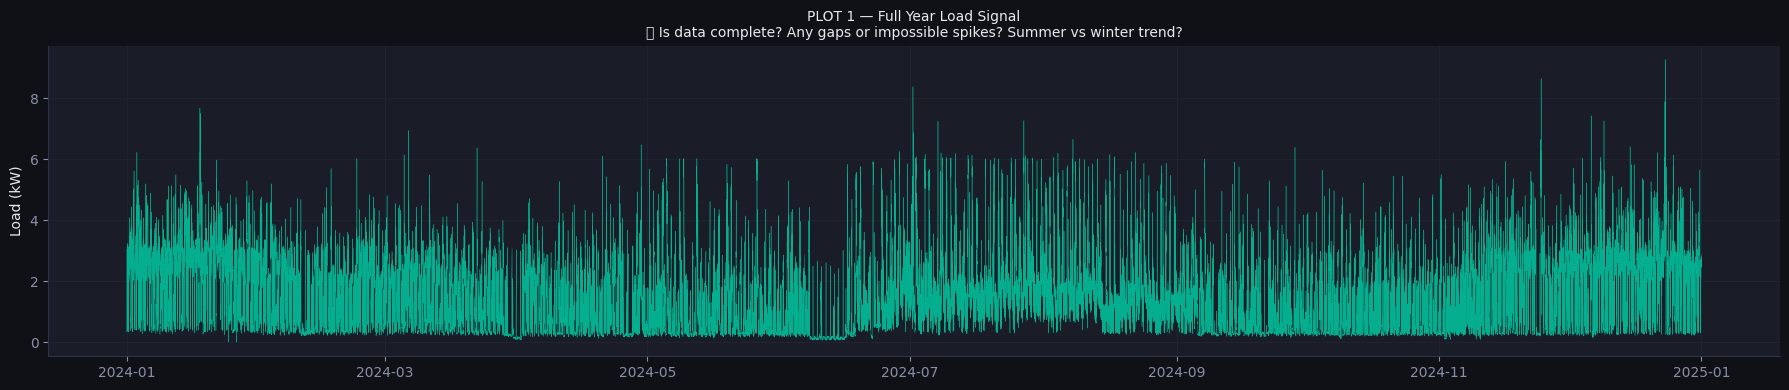

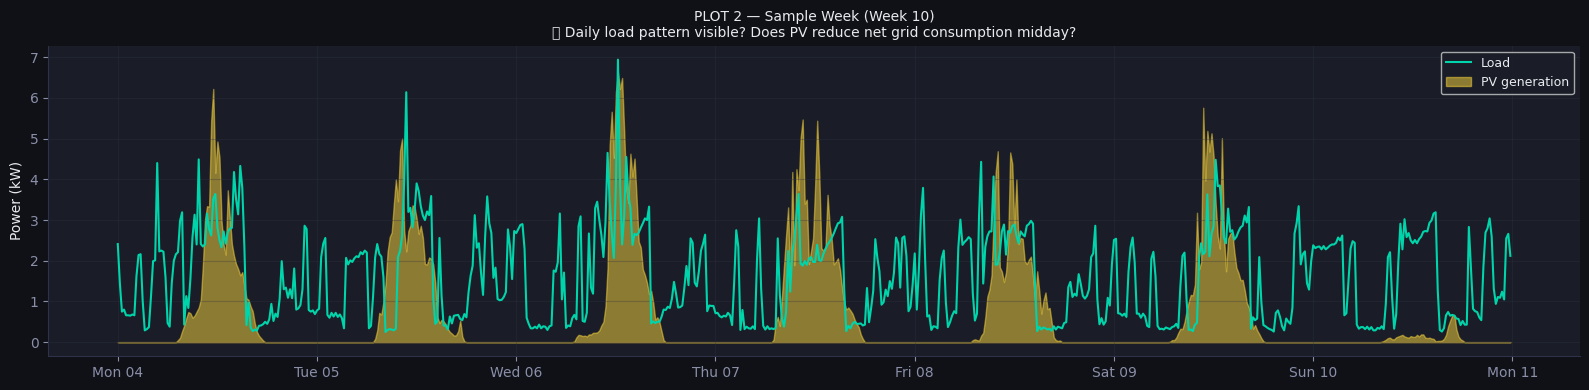

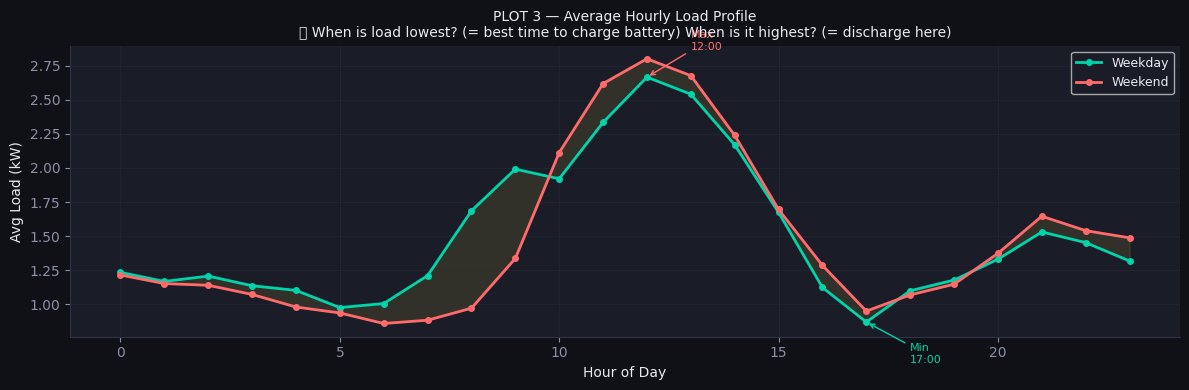

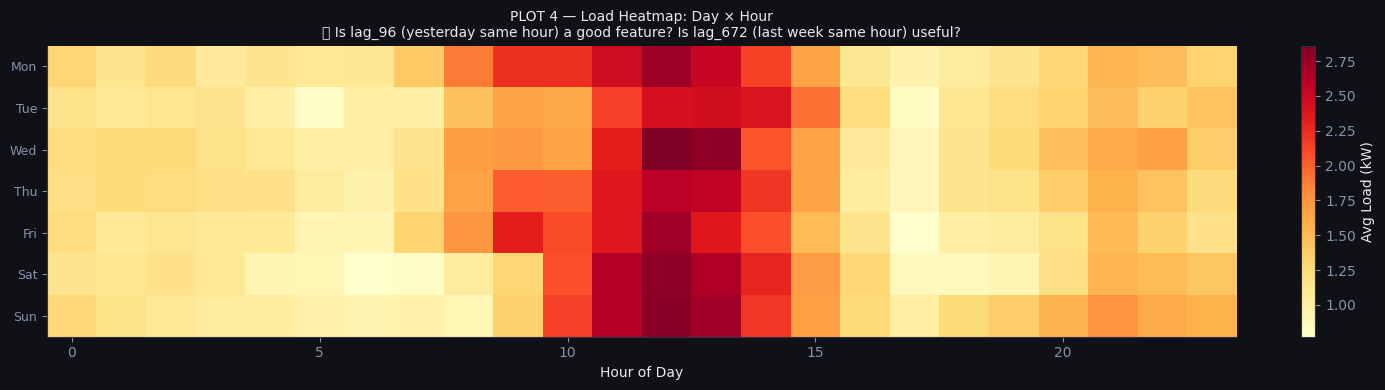

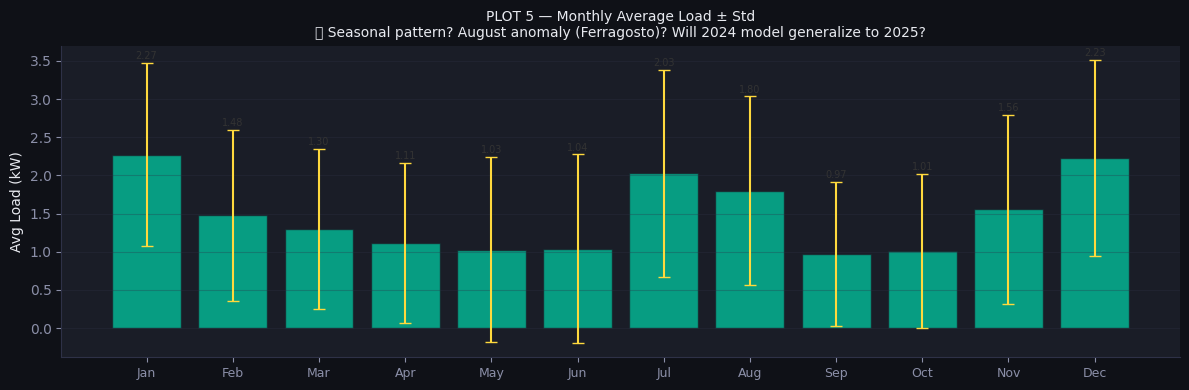

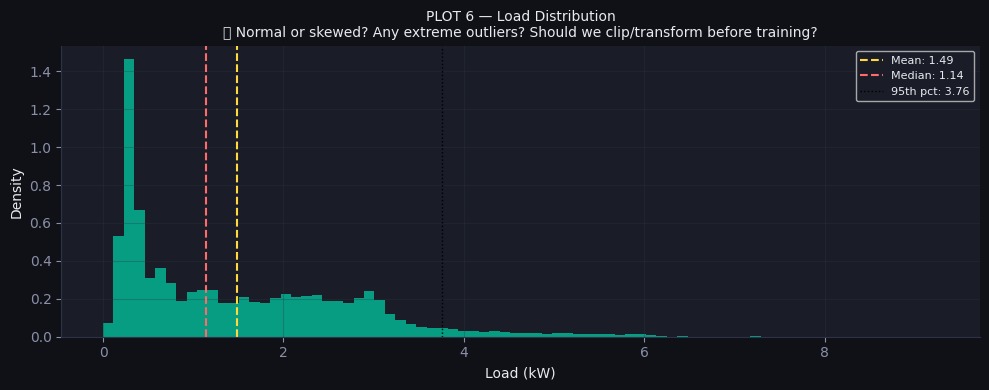

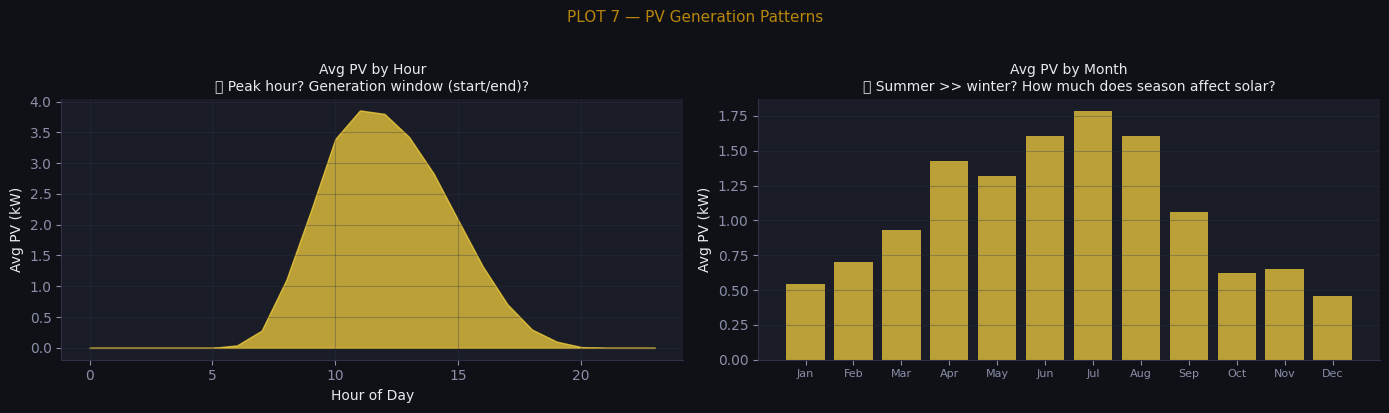

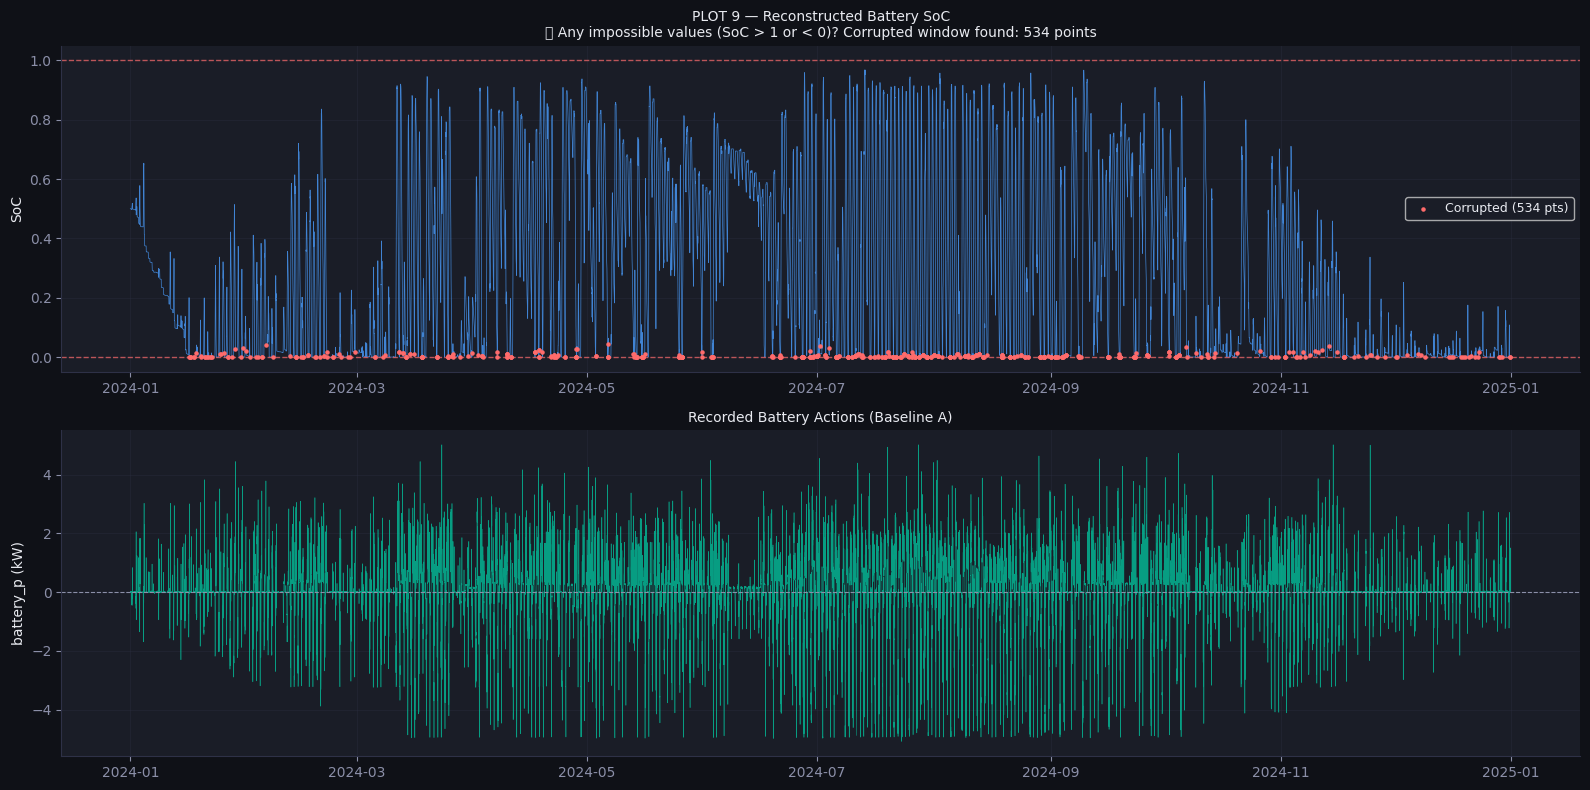


  ⚠️  CORRUPTED DATA DETECTED
     Count : 534 timesteps
     Start : 2024-01-16 15:45:00
     End   : 2024-12-31 19:00:00
     Action: these will be zeroed for Baseline A

✅ EDA complete for 2024
   Read the ❓ question on each plot and write your answers.
   Those answers = your feature engineering decisions.


In [27]:
# Run on 2024 first (training data)
explore_dataset(df_2024, year_label='2024')

#Feature Engineering

Occupied periods : 34,123 rows (97.1%)
Empty periods    : 1,013 rows (2.9%)

Occupied load  → mean: 1.52 kW  max: 9.26 kW
Empty load     → mean: 0.48 kW    max: 5.52 kW


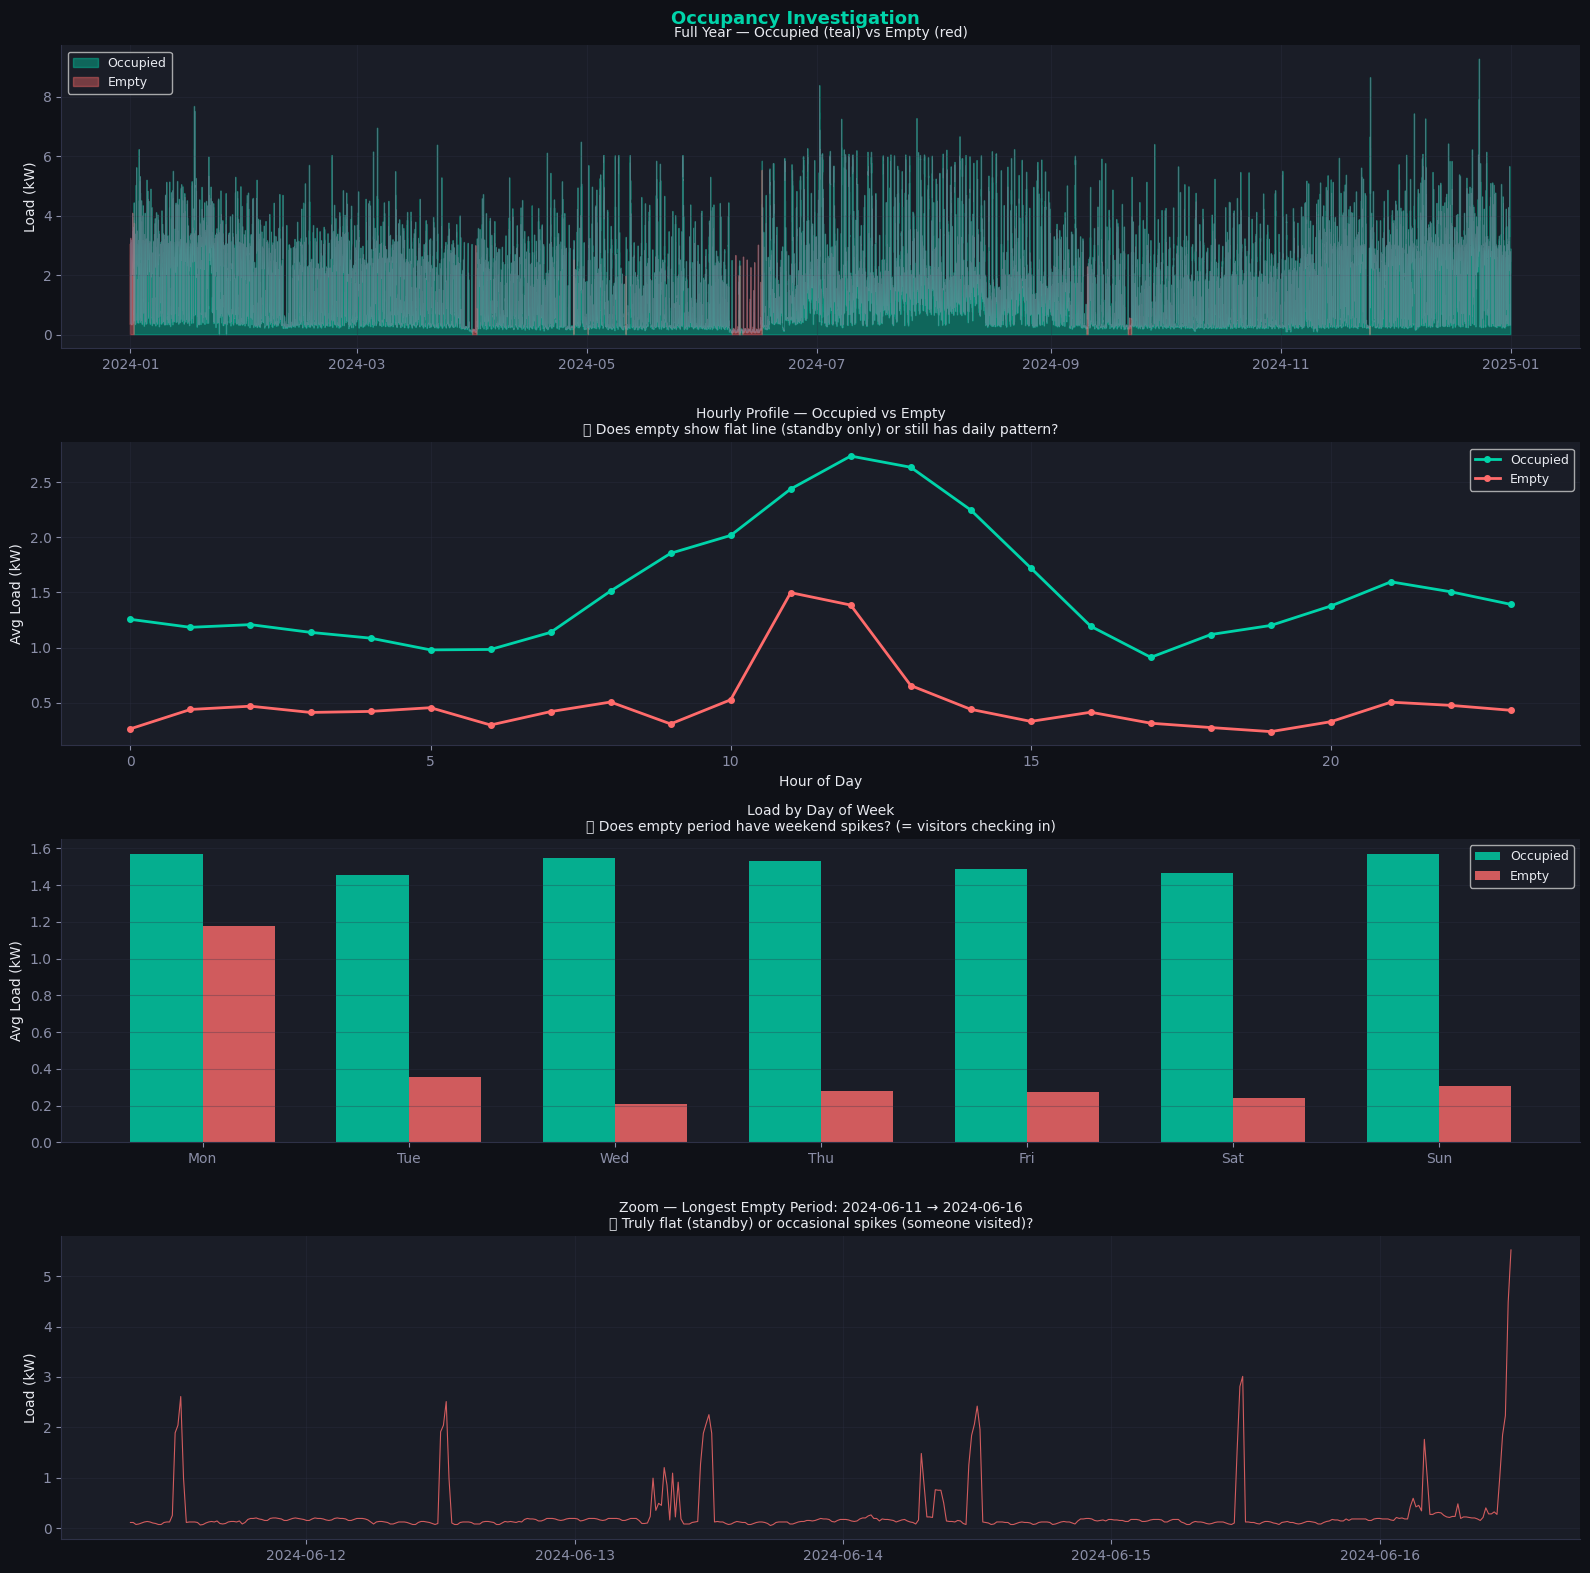

In [28]:
# Add time-based features to df_2024 (as done in explore_dataset)
df_2024['hour']  = df_2024['timestamp'].dt.hour
df_2024['dow']   = df_2024['timestamp'].dt.dayofweek
df_2024['month'] = df_2024['timestamp'].dt.month
df_2024['date']  = df_2024['timestamp'].dt.date

# ── Step 1: Define occupied vs empty based on rolling mean ─────
df_2024['rolling_mean_24h'] = df_2024['load_p'].rolling(96).mean()
df_2024['is_occupied']      = (df_2024['rolling_mean_24h'] > 0.4).astype(int)

occupied = df_2024[df_2024['is_occupied'] == 1]
empty    = df_2024[df_2024['is_occupied'] == 0]

print(f"Occupied periods : {len(occupied):,} rows ({len(occupied)/len(df_2024)*100:.1f}%)")
print(f"Empty periods    : {len(empty):,} rows ({len(empty)/len(df_2024)*100:.1f}%)")
print(f"\nOccupied load  → mean: {occupied['load_p'].mean():.2f} kW  max: {occupied['load_p'].max():.2f} kW")
print(f"Empty load     → mean: {empty['load_p'].mean():.2f} kW    max: {empty['load_p'].max():.2f} kW")

# ── Step 2: Four plots ─────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(16, 16))
fig.suptitle('Occupancy Investigation', fontsize=13, color=TEAL, fontweight='bold')

# Plot A — Full year colored by occupancy
ax = axes[0]
ax.plot(df_2024['timestamp'], df_2024['load_p'], color=GREY, lw=0.3, alpha=0.5)
ax.fill_between(df_2024['timestamp'], df_2024['load_p'],
                where=df_2024['is_occupied']==1, color=TEAL, alpha=0.4, label='Occupied')
ax.fill_between(df_2024['timestamp'], df_2024['load_p'],
                where=df_2024['is_occupied']==0, color=RED,  alpha=0.4, label='Empty')
ax.set_title('Full Year — Occupied (teal) vs Empty (red)', fontsize=10)
ax.set_ylabel('Load (kW)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot B — Hourly profile: occupied vs empty
ax2 = axes[1]
occ_hour   = occupied.groupby('hour')['load_p'].mean()
empty_hour = empty.groupby('hour')['load_p'].mean()
ax2.plot(occ_hour.index,   occ_hour.values,   color=TEAL, lw=2, marker='o', ms=4, label='Occupied')
ax2.plot(empty_hour.index, empty_hour.values, color=RED,  lw=2, marker='o', ms=4, label='Empty')
ax2.set_title('Hourly Profile — Occupied vs Empty\n'
              '❓ Does empty show flat line (standby only) or still has daily pattern?', fontsize=10)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Avg Load (kW)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot C — Day of week: occupied vs empty
ax3 = axes[2]
occ_dow   = occupied.groupby('dow')['load_p'].mean()
empty_dow = empty.groupby('dow')['load_p'].mean()
x = range(7)
w = 0.35
ax3.bar([i - w/2 for i in x], occ_dow.values,   width=w, color=TEAL, alpha=0.8, label='Occupied')
ax3.bar([i + w/2 for i in x], empty_dow.values,  width=w, color=RED,  alpha=0.8, label='Empty')
ax3.set_xticks(range(7))
ax3.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax3.set_title('Load by Day of Week\n'
              '❓ Does empty period have weekend spikes? (= visitors checking in)', fontsize=10)
ax3.set_ylabel('Avg Load (kW)')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# Plot D — Zoom into one empty period
# Find the longest continuous empty stretch
df_2024['empty_block'] = (df_2024['is_occupied'] != df_2024['is_occupied'].shift()).cumsum()
empty_blocks = df_2024[df_2024['is_occupied']==0].groupby('empty_block')['timestamp'].agg(['min','max','count'])
longest = empty_blocks.sort_values('count', ascending=False).iloc[0]

zoom = df_2024[(df_2024['timestamp'] >= longest['min']) &
               (df_2024['timestamp'] <= longest['max'])]

ax4 = axes[3]
ax4.plot(zoom['timestamp'], zoom['load_p'], color=RED, lw=0.8, alpha=0.8)
ax4.set_title(f'Zoom — Longest Empty Period: {longest["min"].date()} → {longest["max"].date()}\n'
              f'❓ Truly flat (standby) or occasional spikes (someone visited)?', fontsize=10)
ax4.set_ylabel('Load (kW)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('occupancy_investigation.png', dpi=120, bbox_inches='tight', facecolor=BG)
plt.show()

Generating ACF and PACF plots for 'load_p'...


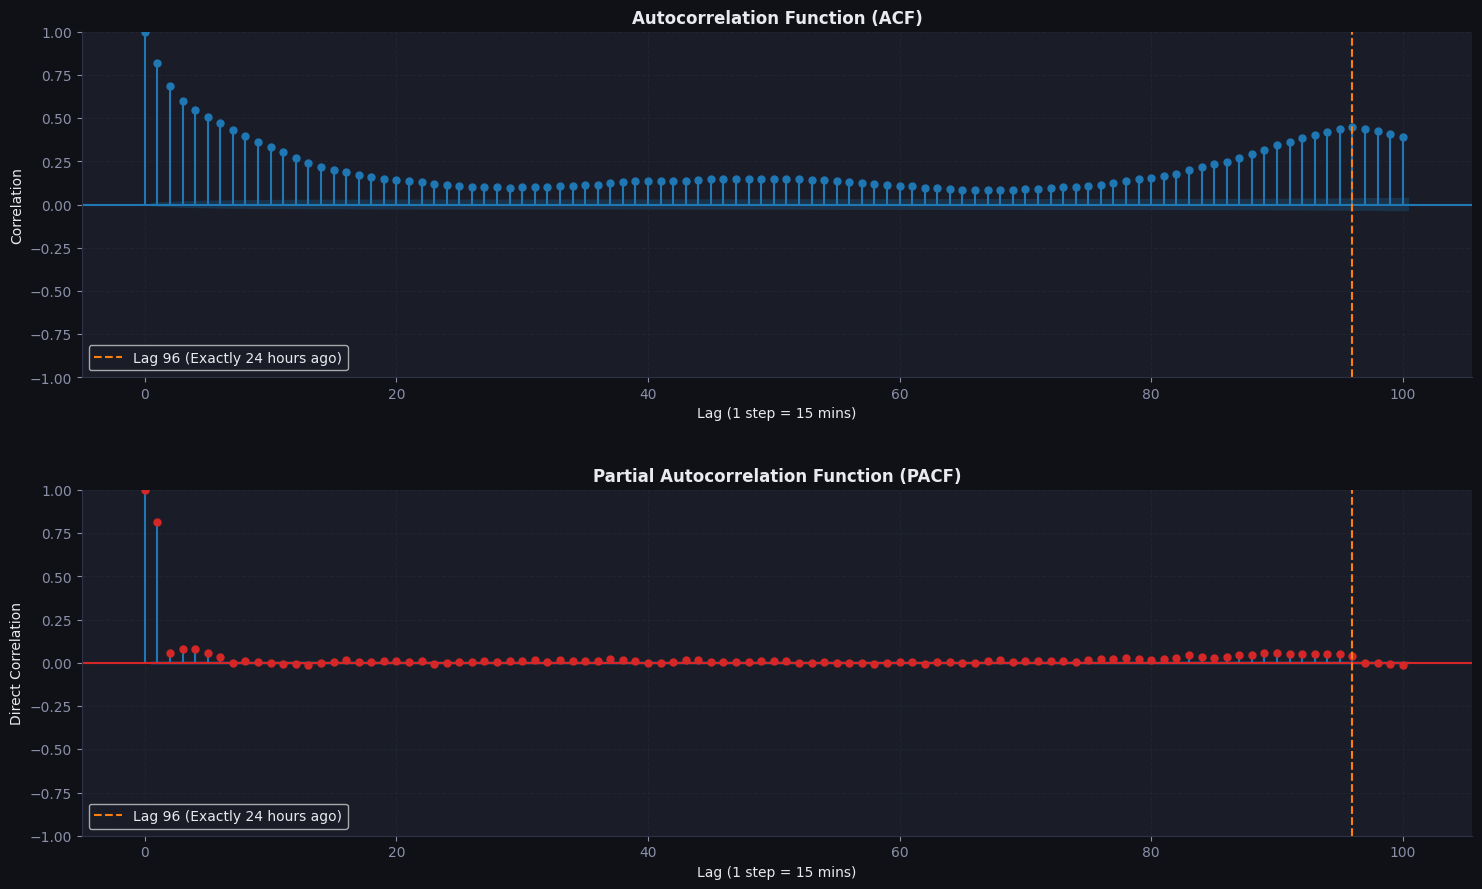

In [29]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(df, target_col='load_p', lags=100):
    """
    Plots ACF and PACF to identify the best lag features for XGBoost.
    """
    print(f"Generating ACF and PACF plots for '{target_col}'...")

    # Drop NaNs just in case, as statsmodels will throw an error
    series = df[target_col].dropna()

    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    fig.tight_layout(pad=6.0)

    # ---------------------------------------------------------
    # 1. ACF Plot
    # ---------------------------------------------------------
    plot_acf(series, ax=axes[0], lags=lags, color='#1f77b4', alpha=0.05)
    axes[0].set_title('Autocorrelation Function (ACF)',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Lag (1 step = 15 mins)')
    axes[0].set_ylabel('Correlation')
    axes[0].grid(True, linestyle='--', alpha=0.3)

    # Highlight the 24-hour mark (lag 96)
    axes[0].axvline(x=96, color='#ff7f0e', linestyle='--', lw=1.5, label='Lag 96 (Exactly 24 hours ago)')
    axes[0].legend()

    # ---------------------------------------------------------
    # 2. PACF Plot
    # ---------------------------------------------------------
    # method='ywm' is generally faster and more stable for large time-series
    plot_pacf(series, ax=axes[1], lags=lags, method='ywm', color='#d62728', alpha=0.05)
    axes[1].set_title('Partial Autocorrelation Function (PACF)',
                      fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Lag (1 step = 15 mins)')
    axes[1].set_ylabel('Direct Correlation')
    axes[1].grid(True, linestyle='--', alpha=0.3)

    # Highlight the 24-hour mark (lag 96)
    axes[1].axvline(x=96, color='#ff7f0e', linestyle='--', lw=1.5, label='Lag 96 (Exactly 24 hours ago)')
    axes[1].legend()

    plt.savefig('acf_pacf_plots.png', dpi=120, bbox_inches='tight', facecolor='white')
    plt.show()



# Run the function on your 2024 data
# Make sure df_2024 is defined and timestamp is sorted!
df_2024 = df_2024.sort_values('timestamp')
plot_acf_pacf(df_2024, target_col='load_p', lags=100)

In [30]:
def engineer_features(df, weather_df, holiday_df, use_weather=True):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)

    # ── CALENDAR ────────────────────────────────────────
    df['hour']       = df['timestamp'].dt.hour
    df['dow']        = df['timestamp'].dt.dayofweek
    df['month']      = df['timestamp'].dt.month
    df['is_weekend'] = (df['dow'] >= 5).astype(int)
    df['is_midday']  = df['hour'].between(10, 14).astype(int)
    df['hour_cos']   = np.cos(2 * np.pi * df['hour']  / 24)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)

    # ── HOLIDAYS ────────────────────────────────────────
    holiday_dates    = set(holiday_df['date'].dt.date)
    df['is_holiday'] = df['timestamp'].dt.date.map(
        lambda d: 1 if d in holiday_dates else 0)

    # ── STABLE LAGS (safe for 24h horizon) ──────────────
    df['lag_1']  = df['load_p'].shift(1)
    df['lag_2']  = df['load_p'].shift(2)
    df['lag_96']  = df['load_p'].shift(96)
    df['lag_192'] = df['load_p'].shift(192)
    df['lag_288'] = df['load_p'].shift(288)
    df['lag_672'] = df['load_p'].shift(672)
    df['lag_mean_3d'] = df[['lag_96', 'lag_192', 'lag_288']].mean(axis=1)
    #df['lag_1yr_dow']  = df['load_p'].shift(34944)

    # ── OCCUPANCY ───────────────────────────────────────
    df['rolling_mean_24h'] = df['load_p'].shift(1).rolling(96).mean()
    df['rolling_max_96']   = df['load_p'].shift(1).rolling(96).max()
    df['is_standby']       = (df['rolling_mean_24h'] < 0.4).astype(int)

    # ── SPIKE PROBABILITY CONTEXT ──────────────────────
    df['was_high_yesterday']  = (df['lag_96'] > 2.0).astype(int)
    df['was_high_last_week']  = (df['lag_672'] > 2.0).astype(int)
    df['high_load_context']   = df['was_high_yesterday'] + df['was_high_last_week']
    df['was_active_yesterday']= (df['rolling_max_96'] > 2.5).astype(int)
    df['lag_96_x_midday']     = df['lag_96'] * df['is_midday']
    df['is_high_spike_month'] = df['month'].isin([1, 2, 7, 8, 11, 12]).astype(int)
    df['ramp_lag_96']         = df['lag_96'] - df['load_p'].shift(97)

    # 1. Day-Hour Interaction (Captures unique daily rhythm)
    df['hour_dow'] = df['hour'] + (df['dow'] * 24)

    # 2. Weekend Morning Momentum
    # (Does the house wake up later on weekends?)
    df['weekend_morning'] = df['is_weekend'] * df['hour'].between(7, 10).astype(int)

    # 3. Consumption Intensity (Is the house currently in a high-usage week?)
    # Compare last week to the week before
    df['weekly_trend'] = df['lag_672'] / (df['load_p'].shift(1344) + 0.1)

    # 4. Correcting the Solar Interaction
    # Instead of just raw irradiance, use the deviation from the 3-day mean
    df['solar_anomaly'] = df['solar_irradiance'] - df['solar_irradiance'].shift(96*3).rolling(96).mean()

    # ── [PRICE] TARIFF BAND FEATURES ───────────────────────────
    # Remove this block + names from SAFE_FEATURES to disable
    import holidays as hols
    it_holidays = hols.Italy(years=[2024, 2025])

    def assign_buy_price(ts):
        h, dow = ts.hour, ts.dayofweek
        is_hol = ts.date() in it_holidays
        if dow == 6 or is_hol:
            return 0.2440, 1   # F3
        if dow == 5:
            return (0.2682, 2) if 7 <= h < 23 else (0.2440, 1)
        if 8 <= h < 19:
            return 0.2540, 3   # F1
        elif (7 <= h < 8) or (19 <= h < 23):
            return 0.2682, 2   # F2
        return 0.2440, 1       # F3

    price_info        = df['timestamp'].apply(assign_buy_price)
    df['buy_price']   = price_info.apply(lambda x: x[0])
    df['band_code']   = price_info.apply(lambda x: x[1])
    df['band_next']   = df['buy_price'].shift(-4)
    df['is_band_changing'] = (df['band_next'] != df['buy_price']).astype(int)

    # ── [WEATHER] ──────────────────────────────────────────────
    # Set use_weather=False for surprise dataset
    if use_weather:
        weather_df['timestamp'] = pd.to_datetime(
            weather_df['timestamp']).dt.round('15min')
        df['timestamp'] = pd.to_datetime(df['timestamp']).dt.round('15min')
        df = df.drop(columns=['temperature_2m', 'solar_irradiance'], errors='ignore')
        df = df.merge(
            weather_df[['timestamp', 'temperature_2m', 'solar_irradiance']],
            on='timestamp', how='left')

        df['heating_degrees'] = np.maximum(18 - df['temperature_2m'], 0)
        df['cooling_degrees'] = np.maximum(df['temperature_2m'] - 24, 0)
        df['cloud_factor']    = np.clip(df['solar_irradiance'] / 900, 0, 1)
        df['solar_drop_15m']  = (df['solar_irradiance'].shift(1)
                                  - df['solar_irradiance']).fillna(0)

        df['pv_lag_96']       = df['solar_irradiance'].shift(96)
        df['pv_x_midday']     = df['pv_lag_96'] * df['is_midday']


        # ── 8. SPIKE PREDICTION FEATURES (Based on Data Analysis) ────

        # 1. The Danger Zone: Is it the high-risk time of day?
        df['is_lunch_peak'] = df['hour'].between(11, 15).astype(int)

        # 2. Thermal Interaction: Cooking + Heating/Cooling = Massive Spike
        # These features tell the model: "If it's lunchtime AND freezing, expect a massive number."
        df['lunch_heating_danger'] = df['is_lunch_peak'] * df['heating_degrees']
        df['lunch_cooling_danger'] = df['is_lunch_peak'] * df['cooling_degrees']

        # 3. Sunday Behavior Isolation
        # Sunday (6) is your highest spike day. Separate it from Saturday.
        df['is_sunday'] = (df['dow'] == 6).astype(int)

        # 4. The "Ramp-Up" Proxy (Using yesterday to guess today's momentum)
        # If the load was ramping up at this exact time yesterday, it probably will today.
        df['lag_96_ramp_15m'] = df['lag_96'] - df['load_p'].shift(97) # Did yesterday jump right here?
        df['lag_96_ramp_15m'] = df['lag_96_ramp_15m'].fillna(0)

        df["lag96_vs_mean"] = df["lag_96"] - df["rolling_mean_24h"]

    return df



SAFE_FEATURES = [
    'lag_96', 'lag_672', 'lag_mean_3d',
    'hour_cos', 'month_cos', 'is_weekend', 'is_holiday',
    'hour_dow', 'weekend_morning', 'weekly_trend', # New
    'is_standby', 'rolling_max_96',
    'buy_price', 'band_code',
    'heating_degrees', 'cooling_degrees', 'solar_anomaly', # New
    'lunch_heating_danger', 'is_sunday'
]


TARGET_COL = 'load_p'

# ── BUILD DATASETS ─────────────────────────────────────────────
weather_df = fetch_sondrio_weather()

holiday_df = generate_italian_holidays()




Fetching hourly weather data for Sondrio and interpolating to 15-min...
Success! Interpolated down to 78909 15-minute rows.
Generating Italian public holidays for 2024 and 2025...
Success! Found 26 holidays.


#Model


✅ Imports ready
Training up to: 2025-04-01
  Train : 36,768 rows  (up to 2025-02-01)
  Val   : 5,664 rows  (2025-02-01 → 2025-04-01)
[0]	validation_0-rmse:1.23085
[100]	validation_0-rmse:1.02215
[200]	validation_0-rmse:1.01445
[300]	validation_0-rmse:1.01468
[400]	validation_0-rmse:1.01570
[408]	validation_0-rmse:1.01562

── Validation (last 2 months) ──
  RMSE  = 1.0131 kW
  MAE   = 0.8011 kW
  NRMSE = 62.50%

Running April 2025: 2025-04-01 → 2025-05-01 (30 days)

── April 2025 (2025-04-01 → 2025-05-01) ──
  RMSE  = 0.9479 kW
  MAE   = 0.6751 kW
  NRMSE = 98.32%


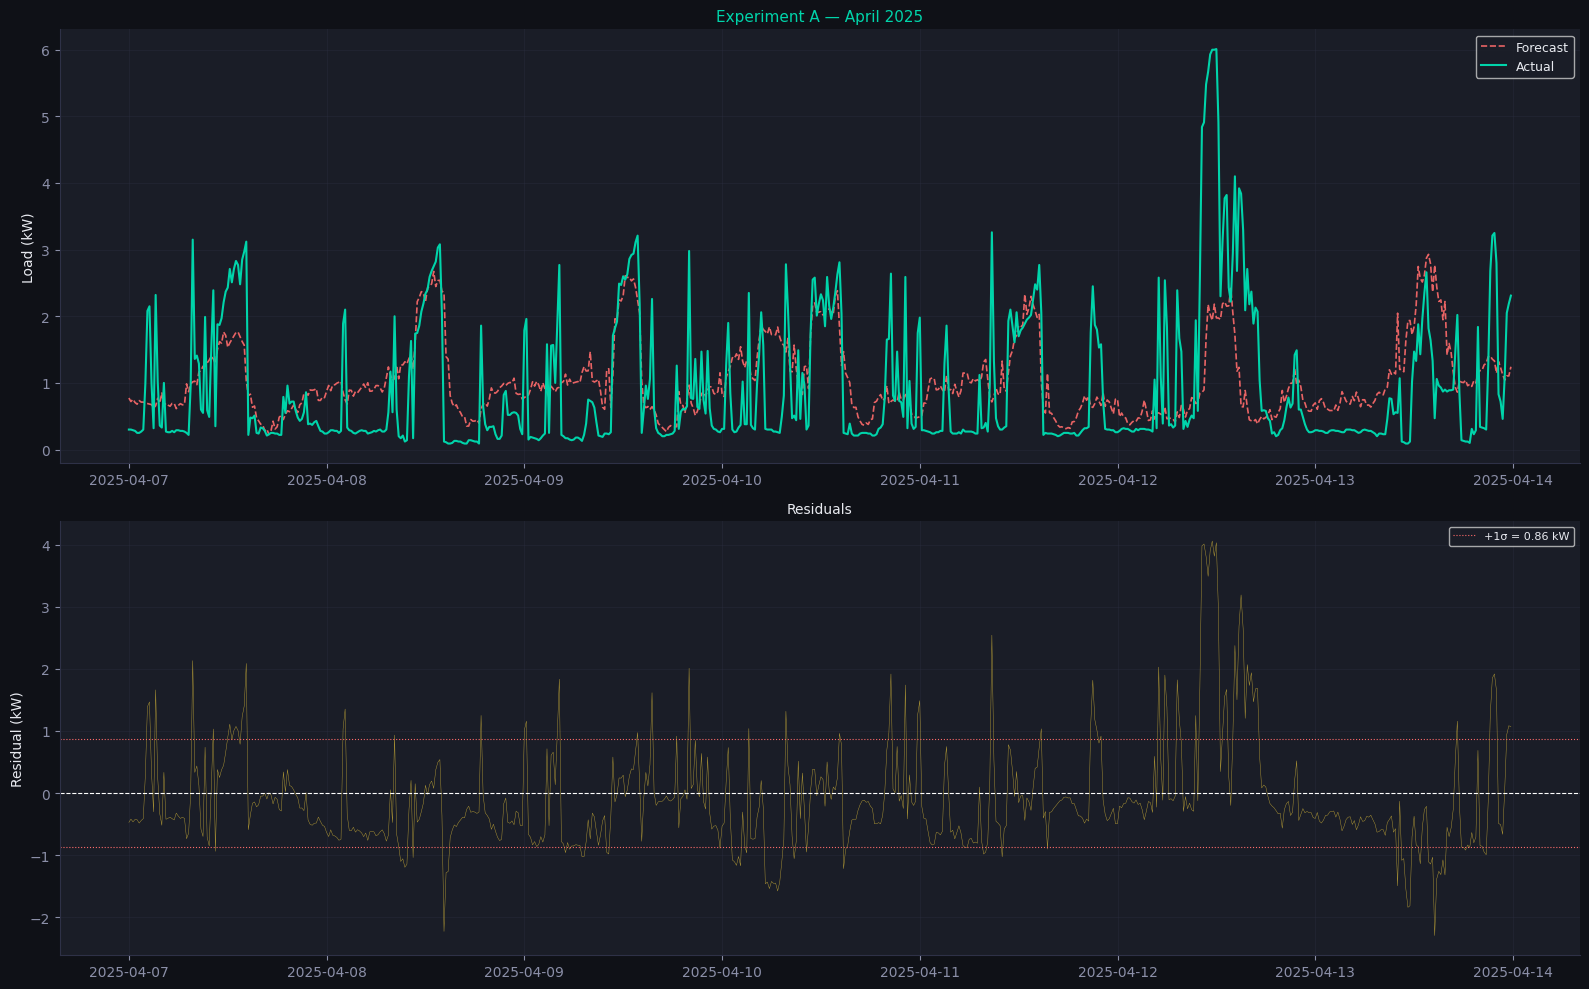

Training up to: 2025-09-01
  Train : 51,168 rows  (up to 2025-07-01)
  Val   : 5,952 rows  (2025-07-01 → 2025-09-01)
[0]	validation_0-rmse:1.28166
[100]	validation_0-rmse:0.93853
[200]	validation_0-rmse:0.93559
[300]	validation_0-rmse:0.93816
[359]	validation_0-rmse:0.93980

── Validation (last 2 months) ──
  RMSE  = 0.9347 kW
  MAE   = 0.6796 kW
  NRMSE = 71.85%

Running September 2025: 2025-09-01 → 2025-10-01 (30 days)

── September 2025 (2025-09-01 → 2025-10-01) ──
  RMSE  = 0.7675 kW
  MAE   = 0.5356 kW
  NRMSE = 91.56%


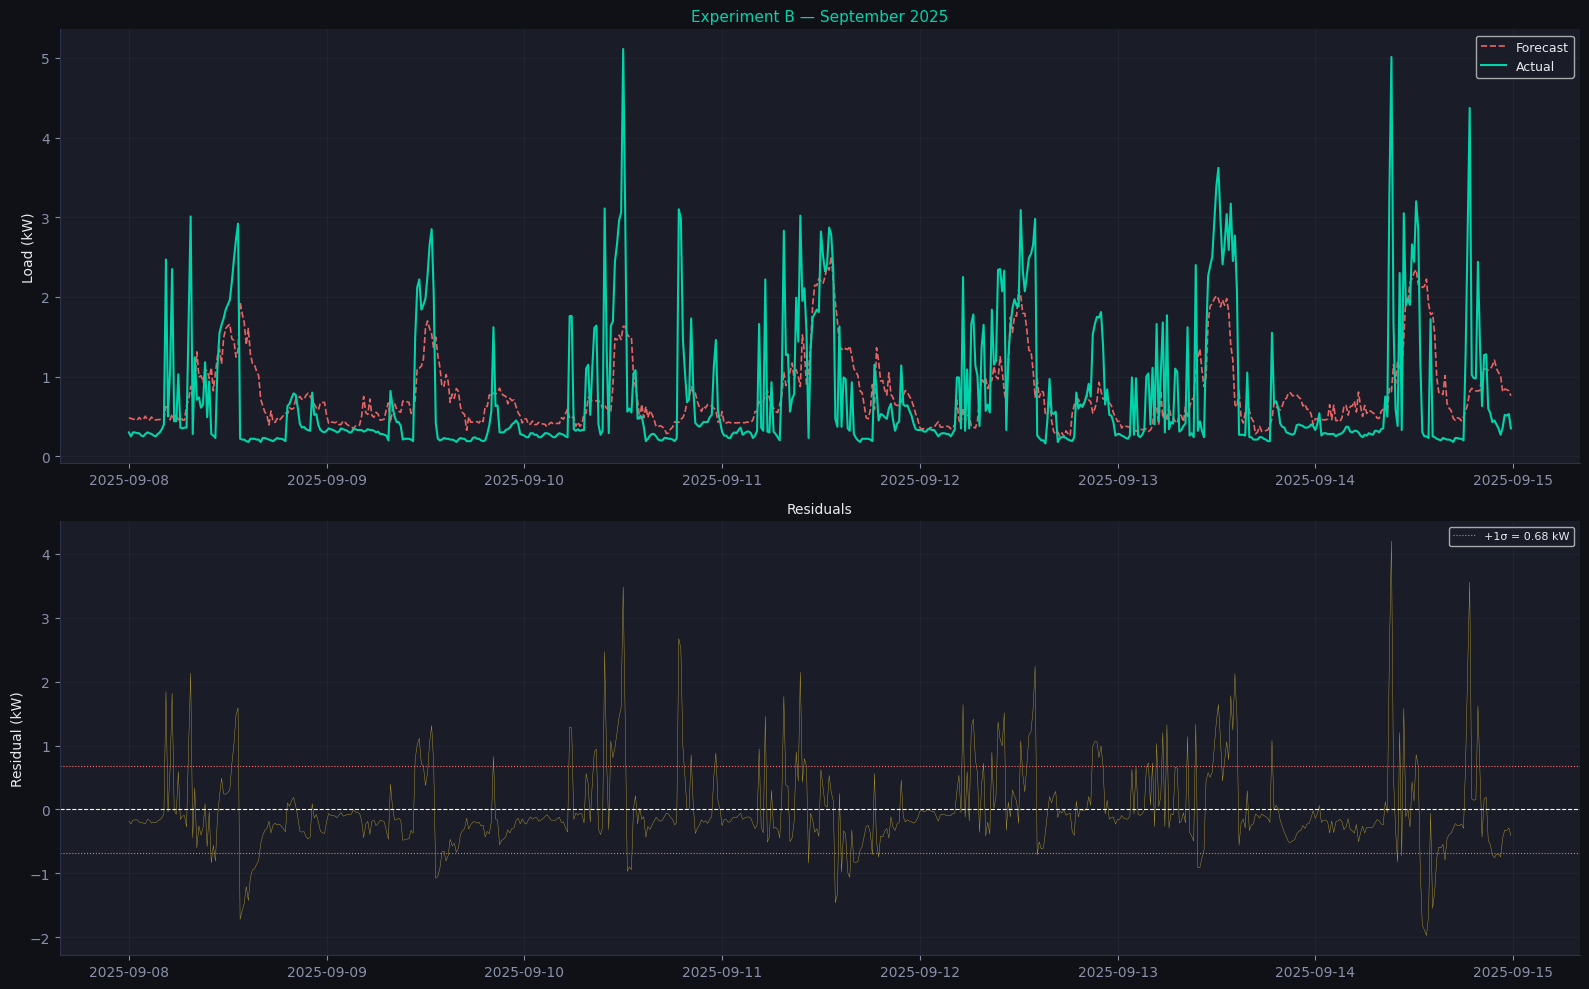

Training up to: 2026-01-01
  Train : 62,976 rows  (up to 2025-11-01)
  Val   : 5,856 rows  (2025-11-01 → 2026-01-01)
[0]	validation_0-rmse:1.35687
[100]	validation_0-rmse:1.12406
[200]	validation_0-rmse:1.13653
[248]	validation_0-rmse:1.14128

── Validation (last 2 months) ──
  RMSE  = 1.1236 kW
  MAE   = 0.8724 kW
  NRMSE = 57.63%

Week-ahead forecast: 2026-01-01 → 2026-01-08
  2026-01-01 — mean: 2.391 kW
  2026-01-02 — mean: 1.876 kW
  2026-01-03 — mean: 1.758 kW
  2026-01-04 — mean: 1.782 kW
  2026-01-05 — mean: 1.805 kW
  2026-01-06 — mean: 1.761 kW
  2026-01-07 — mean: 1.900 kW

✅ 672 predictions saved


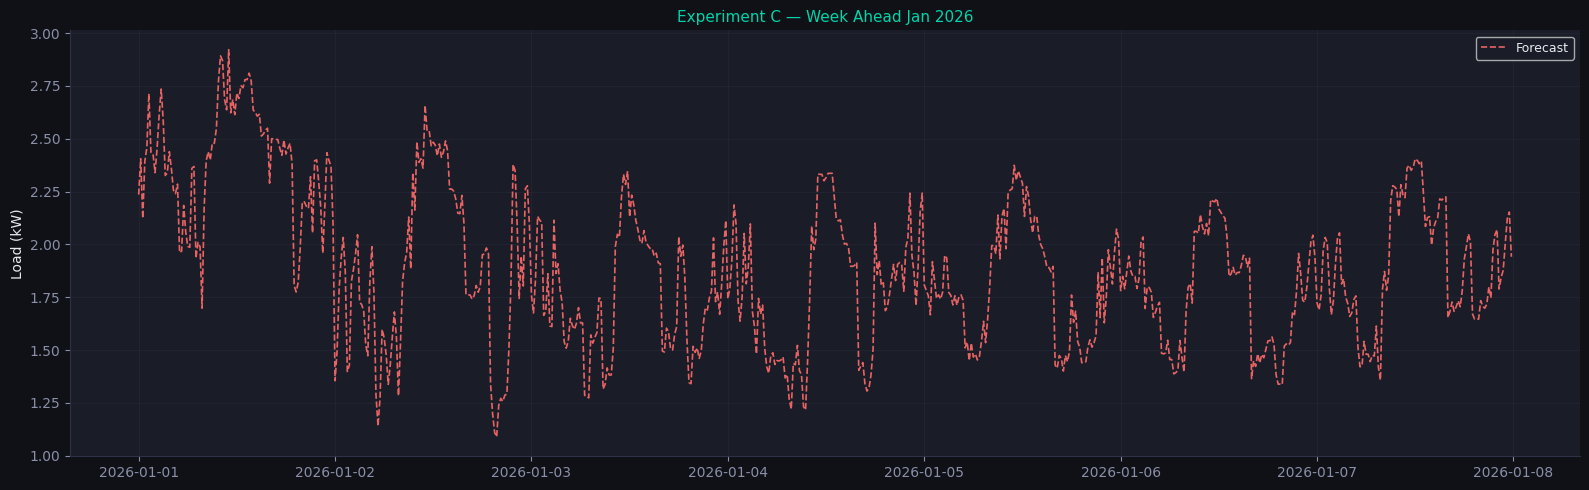


  EXPERIMENT COMPARISON
  Experiment                             NRMSE
  ---------------------------------------------
  A — April 2025  (trained to Mar 2025)   98.32%
  B — Sept 2025   (trained to Aug 2025)   91.56%
  C — Jan 2026 (no actuals to compare)


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import os, warnings
warnings.filterwarnings('ignore')

def compute_metrics(y_true, y_pred, label=''):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    nrmse = rmse / np.mean(y_true) * 100
    if label:
        print(f"\n── {label} ──")
        print(f"  RMSE  = {rmse:.4f} kW")
        print(f"  MAE   = {mae:.4f} kW")
        print(f"  NRMSE = {nrmse:.2f}%")
    return rmse, mae, nrmse

print("✅ Imports ready")


def train_model(df_combined_feat, safe_features, target_col,
                train_end, val_months=2):

    train_end_ts = pd.Timestamp(train_end)
    val_start_ts = train_end_ts - pd.DateOffset(months=val_months)

    df_train = df_combined_feat[
        df_combined_feat['timestamp'] < train_end_ts
    ].dropna(subset=safe_features + [target_col]).copy()

    train = df_train[df_train['timestamp'] < val_start_ts]
    val   = df_train[df_train['timestamp'] >= val_start_ts]

    X_train, y_train = train[safe_features], train[target_col]
    X_val,   y_val   = val[safe_features],   val[target_col]

    print(f"Training up to: {train_end}")
    print(f"  Train : {len(X_train):,} rows  (up to {val_start_ts.date()})")
    print(f"  Val   : {len(X_val):,} rows  ({val_start_ts.date()} → {train_end})")

    # FIXED: Added early_stopping_rounds here inside the constructor
    model = xgb.XGBRegressor(
        objective         = 'reg:squarederror',
        n_estimators      = 2000,
        max_depth         = 7,
        learning_rate     = 0.03,
        subsample         = 0.9,
        colsample_bytree  = 0.6,
        colsample_bylevel = 0.8,
        min_child_weight  = 10,
        reg_alpha         = 0.1,
        reg_lambda        = 1.5,
        early_stopping_rounds = 150,
        random_state      = 42
    )

    # FIXED: Removed early_stopping_rounds from here
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=100)

    val_pred = np.maximum(model.predict(X_val), 0)
    compute_metrics(y_val, val_pred, label=f'Validation (last {val_months} months)')

    return model



def batch_predict(model, df_combined_feat, safe_features, target_col,
                  test_start, test_end, label='Test'):
    """
    Batch prediction on a test window, uses actual lag values
    """
    df_test = df_combined_feat[
        (df_combined_feat['timestamp'] >= test_start) &
        (df_combined_feat['timestamp'] <  test_end)
    ].copy().reset_index(drop=True)

    pred = np.maximum(model.predict(df_test[safe_features]), 0)
    df_test['load_forecast'] = pred

    y_true = df_test[target_col].values
    compute_metrics(y_true, pred, label=f'{label} ({test_start} → {test_end})')

    return df_test, pred



def recursive_day_ahead(model, df_combined_feat, safe_features, target_col,
                        test_start, test_end, label='Recursive'):
    """
    Day-ahead recursive prediction.
    Reseeds from actual data every midnight.
    lag_mean_3d, lag_672 always use actual data.
    Rolling features frozen at morning actuals.
    """
    feature_map = {name: i for i, name in enumerate(safe_features)}

    # Pre-fetching indices to speed up the loop
    fm_lag_mean_3d = feature_map.get('lag_mean_3d')
    fm_lag_672 = feature_map.get('lag_672')
    fm_is_midday = feature_map.get('is_midday')
    fm_lag_96_x_midday = feature_map.get('lag_96_x_midday')
    fm_high_load_context = feature_map.get('high_load_context')
    fm_ramp_lag_96 = feature_map.get('ramp_lag_96')
    fm_lag96_vs_mean = feature_map.get('lag96_vs_mean')
    fm_rolling_max_96 = feature_map.get('rolling_max_96')
    fm_is_standby = feature_map.get('is_standby')
    fm_was_active_yesterday = feature_map.get('was_active_yesterday')

    df_test = df_combined_feat[
        (df_combined_feat['timestamp'] >= test_start) &
        (df_combined_feat['timestamp'] <  test_end)
    ].copy().reset_index(drop=True)

    # Full history including test actuals (for morning reseed)
    df_all_actuals = df_combined_feat.set_index('timestamp')[target_col].sort_index()

    X_vals   = df_test[safe_features].values.astype(float)
    pred_out = np.zeros(len(df_test))

    df_test['_date'] = df_test['timestamp'].dt.date
    days = sorted(df_test['_date'].unique())

    print(f"\nRunning {label}: {test_start} → {test_end} ({len(days)} days)")

    for day in days:
        day_indices = df_test.index[df_test['_date'] == day].tolist()
        day_start   = pd.Timestamp(day)

        # Morning reseed with actual data
        actuals_before = df_all_actuals[df_all_actuals.index < day_start].values
        history        = list(actuals_before[-672:])

        # Morning context from real data
        h96             = np.array(history[-96:])
        morning_mean    = float(np.mean(h96))
        morning_max     = float(np.max(h96))
        morning_standby = 1 if morning_mean < 0.4 else 0
        morning_active  = 1 if morning_max  > 2.5 else 0
        standby_cap     = float(np.interp(
            morning_mean, [0.0, 0.4, 1.0], [0.3, 0.5, 99.0]))

        for step, row_i in enumerate(day_indices):
            row = X_vals[row_i]

            # Long lags — always actual (reseed covers 672 steps)
            if fm_lag_mean_3d is not None:
                l96  = history[-96]
                l192 = history[-192] if len(history) >= 192 else l96
                l288 = history[-288] if len(history) >= 288 else l96
                row[fm_lag_mean_3d] = (l96 + l192 + l288) / 3.0

            if fm_lag_672 is not None:
                row[fm_lag_672] = history[-672] if len(history) >= 672 else history[0]

            lag96_val = history[-96]  # always actual

            if fm_lag_96_x_midday is not None:
                is_midday = float(row[fm_is_midday]) if fm_is_midday is not None else 0.0
                row[fm_lag_96_x_midday] = lag96_val * is_midday

            if fm_high_load_context is not None:
                lag672 = history[-672] if len(history) >= 672 else lag96_val
                row[fm_high_load_context] = (
                    (1 if lag96_val > 2.0 else 0) +
                    (1 if lag672    > 2.0 else 0))

            if fm_ramp_lag_96 is not None:
                lag97 = history[-97] if len(history) >= 97 else lag96_val
                row[fm_ramp_lag_96] = lag96_val - lag97

            if fm_lag96_vs_mean is not None:
                row[fm_lag96_vs_mean] = lag96_val - morning_mean

            # Rolling features — frozen at morning actuals
            if fm_rolling_max_96 is not None: row[fm_rolling_max_96]       = morning_max
            if fm_is_standby is not None: row[fm_is_standby]           = morning_standby
            if fm_was_active_yesterday is not None: row[fm_was_active_yesterday] = morning_active

            pred = float(model.predict(row.reshape(1, -1))[0])
            pred = max(pred, 0.0)
            pred = min(pred, standby_cap)

            pred_out[row_i] = pred
            history.append(pred)
            if len(history) > 672:
                history.pop(0)

        # FIXED INDENTATION: Predict the sum for the day based on yesterday's total
        yesterday_total = np.sum(h96) * 0.25 # kWh
        predicted_day_vol = np.sum(pred_out[day_indices]) * 0.25

        # If the day's total energy is wildly different from yesterday's
        # (and weather is similar), scale it back slightly toward reality
        if abs(predicted_day_vol - yesterday_total) > 10.0:
            correction = yesterday_total / (predicted_day_vol + 0.1)
            pred_out[day_indices] *= np.clip(correction, 0.8, 1.2)

    df_test['load_forecast'] = pred_out
    y_true = df_test[target_col].values
    compute_metrics(y_true, pred_out,
                    label=f'{label} ({test_start} → {test_end})')

    return df_test, pred_out


def recursive_week_ahead(model, df_combined_feat, safe_features,
                         predict_start, predict_end,
                         weather_df, holiday_df):


    feature_map = {name: i for i, name in enumerate(safe_features)}

    fm_lag_mean_3d = feature_map.get('lag_mean_3d')
    fm_lag_672 = feature_map.get('lag_672')
    fm_lag_96 = feature_map.get('lag_96')
    fm_is_midday = feature_map.get('is_midday')
    fm_lag_96_x_midday = feature_map.get('lag_96_x_midday')
    fm_high_load_context = feature_map.get('high_load_context')
    fm_ramp_lag_96 = feature_map.get('ramp_lag_96')
    fm_lag96_vs_mean = feature_map.get('lag96_vs_mean')
    fm_rolling_max_96 = feature_map.get('rolling_max_96')
    fm_is_standby = feature_map.get('is_standby')
    fm_was_active_yesterday = feature_map.get('was_active_yesterday')

    # Build future dataframe
    future_ts = pd.date_range(
        start=predict_start, end=predict_end,
        freq='15min', inclusive='left')
    df_future = pd.DataFrame({'timestamp': future_ts, 'load_p': 0.0})

    # Combine with history tail for lag engineering
    history_tail = df_combined_feat.tail(700).copy()
    df_for_feats = pd.concat([history_tail, df_future], ignore_index=True)
    df_for_feats = engineer_features(
        df_for_feats, weather_df, holiday_df, use_weather=True)

    df_week = df_for_feats[
        df_for_feats['timestamp'] >= predict_start
    ].copy().reset_index(drop=True)

    X_week   = df_week[safe_features].values.astype(float)
    pred_out = []

    # Seed with actual history
    actual_history = (
        df_combined_feat[df_combined_feat['timestamp'] < predict_start]
        ['load_p'].tail(700).tolist()
    )

    df_week['_date'] = df_week['timestamp'].dt.date
    days = sorted(df_week['_date'].unique())

    print(f"\nWeek-ahead forecast: {predict_start} → {predict_end}")

    for day in days:
        day_indices = df_week.index[df_week['_date'] == day].tolist()

        # Morning reseed from actual_history
        history = list(actual_history[-672:])

        h96             = np.array(history[-96:])
        morning_mean    = float(np.mean(h96))
        morning_max     = float(np.max(h96))
        morning_standby = 1 if morning_mean < 0.4 else 0
        morning_active  = 1 if morning_max  > 2.5 else 0
        standby_cap     = float(np.interp(
            morning_mean, [0.0, 0.4, 1.0], [0.3, 0.5, 99.0]))

        for step, row_i in enumerate(day_indices):
            row = X_week[row_i]

            if fm_lag_mean_3d is not None:
                l96  = history[-96]
                l192 = history[-192] if len(history) >= 192 else l96
                l288 = history[-288] if len(history) >= 288 else l96
                row[fm_lag_mean_3d] = (l96 + l192 + l288) / 3.0

            if fm_lag_672 is not None:
                row[fm_lag_672] = history[-672] if len(history) >= 672 else history[0]

            lag96_val = history[-96]

            if fm_lag_96 is not None:
                row[fm_lag_96] = lag96_val

            if fm_lag_96_x_midday is not None:
                is_midday = float(row[fm_is_midday]) if fm_is_midday is not None else 0.0
                row[fm_lag_96_x_midday] = lag96_val * is_midday

            if fm_high_load_context is not None:
                lag672 = history[-672] if len(history) >= 672 else lag96_val
                row[fm_high_load_context] = (
                    (1 if lag96_val > 2.0 else 0) +
                    (1 if lag672    > 2.0 else 0))

            if fm_ramp_lag_96 is not None:
                lag97 = history[-97] if len(history) >= 97 else lag96_val
                row[fm_ramp_lag_96] = lag96_val - lag97

            if fm_lag96_vs_mean is not None:
                row[fm_lag96_vs_mean] = lag96_val - morning_mean

            if fm_rolling_max_96 is not None: row[fm_rolling_max_96]       = morning_max
            if fm_is_standby is not None: row[fm_is_standby]           = morning_standby
            if fm_was_active_yesterday is not None: row[fm_was_active_yesterday] = morning_active

            pred = float(model.predict(row.reshape(1, -1))[0])
            pred = max(pred, 0.0)
            pred = min(pred, standby_cap)

            pred_out.append(pred)
            history.append(pred)
            actual_history.append(pred)  # feeds next day's reseed
            if len(history) > 672:
                history.pop(0)

        print(f"  {day} — mean: {np.mean(pred_out[-96:]):.3f} kW")

    submission = pd.DataFrame({
        'timestamp':     df_week['timestamp'],
        'load_forecast': pred_out,
    })

    return submission



def plot_forecast(df_result, title='Forecast vs Actual',
                  actual_col='load_p', pred_col='load_forecast',
                  sample_start=None, sample_end=None):

    df_plot = df_result.copy()
    if sample_start:
        df_plot = df_plot[df_plot['timestamp'] >= sample_start]
    if sample_end:
        df_plot = df_plot[df_plot['timestamp'] <  sample_end]

    has_actual = actual_col in df_plot.columns and df_plot[actual_col].sum() > 0

    fig, axes = plt.subplots(2 if has_actual else 1, 1,
                              figsize=(16, 10 if has_actual else 5))
    if not has_actual:
        axes = [axes]

    axes[0].plot(df_plot['timestamp'], df_plot[pred_col],
                 color='#ff6b6b', lw=1.2, ls='--', label='Forecast', alpha=0.9)
    if has_actual:
        axes[0].plot(df_plot['timestamp'], df_plot[actual_col],
                     color='#00d4aa', lw=1.5, label='Actual')
    axes[0].set_title(title, fontsize=11, color='#00d4aa')
    axes[0].set_ylabel('Load (kW)')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    if has_actual:
        residuals = df_plot[actual_col].values - df_plot[pred_col].values
        axes[1].plot(df_plot['timestamp'], residuals,
                     color='#ffd93d', lw=0.3, alpha=0.7)
        axes[1].axhline(0, color='white', lw=0.8, ls='--')
        axes[1].axhline( residuals.std(), color='#ff6b6b', lw=0.8, ls=':',
                         label=f'+1σ = {residuals.std():.2f} kW')
        axes[1].axhline(-residuals.std(), color='#ff6b6b', lw=0.8, ls=':')
        axes[1].set_ylabel('Residual (kW)')
        axes[1].set_title('Residuals', fontsize=10)
        axes[1].legend(fontsize=8)
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ','_')}.png", dpi=120,
                bbox_inches='tight', facecolor='#0f1117')
    plt.show()




df_combined = pd.concat([df_2024, df_2025]).sort_values('timestamp').reset_index(drop=True)
df_combined_feat = engineer_features(df_combined, weather_df, holiday_df, use_weather=True)

# First test

model_A = train_model(
    df_combined_feat, SAFE_FEATURES, TARGET_COL,
    train_end='2025-04-01',
    val_months=2,
)

df_A, pred_A = recursive_day_ahead(
    model_A, df_combined_feat, SAFE_FEATURES, TARGET_COL,
    test_start='2025-04-01',
    test_end  ='2025-05-01',
    label='April 2025',
)

plot_forecast(df_A, title='Experiment A — April 2025',
              sample_start='2025-04-07', sample_end='2025-04-14')




# Second  test

model_B = train_model(
    df_combined_feat, SAFE_FEATURES, TARGET_COL,
    train_end='2025-09-01',
    val_months=2,
)

df_B, pred_B = recursive_day_ahead(
    model_B, df_combined_feat, SAFE_FEATURES, TARGET_COL,
    test_start='2025-09-01',
    test_end  ='2025-10-01',
    label='September 2025',
)

plot_forecast(df_B, title='Experiment B — September 2025',
              sample_start='2025-09-08', sample_end='2025-09-15')


# Third test

model_C = train_model(
    df_combined_feat, SAFE_FEATURES, TARGET_COL,
    train_end='2026-01-01',   # full 2024+2025
    val_months=2,
)

submission = recursive_week_ahead(
    model_C, df_combined_feat, SAFE_FEATURES,
    predict_start='2026-01-01',
    predict_end  ='2026-01-08',
    weather_df=weather_df,
    holiday_df=holiday_df,
)

os.makedirs('Data/output', exist_ok=True)
submission.to_csv('Data/output/forecast_jan2026.csv', index=False)
print(f"\n✅ {len(submission)} predictions saved")

plot_forecast(submission,
              title='Experiment C — Week Ahead Jan 2026',
              actual_col='load_p')  # no actuals — shows forecast only


# compare

print("\n" + "="*55)
print("  EXPERIMENT COMPARISON")
print("="*55)
print(f"  {'Experiment':<35} {'NRMSE':>8}")
print(f"  {'-'*45}")

for label, df_res, pred in [
    ('A — April 2025  (trained to Mar 2025)', df_A, pred_A),
    ('B — Sept 2025   (trained to Aug 2025)', df_B, pred_B),
]:
    _, _, nrmse = compute_metrics(
        df_res[TARGET_COL].values, pred)
    print(f"  {label:<35} {nrmse:>7.2f}%")

print("="*55)
print("  C — Jan 2026 (no actuals to compare)")
print("="*55)

 1. DEBUGGING THE FLAT LINE (Last Week of 2025)
Date            | Daily Mean   | Daily Max    | Next Day Cap   
-----------------------------------------------------------------
2025-12-25      |   1.881 kW |   6.260 kW |      99.00 kW
2025-12-26      |   2.258 kW |   6.670 kW |      99.00 kW
2025-12-27      |   2.402 kW |   7.750 kW |      99.00 kW
2025-12-28      |   2.135 kW |   4.850 kW |      99.00 kW
2025-12-29      |   2.323 kW |   4.870 kW |      99.00 kW
2025-12-30      |   2.251 kW |   5.910 kW |      99.00 kW
2025-12-31      |   2.251 kW |   5.910 kW |      99.00 kW

 2. YEAR-OVER-YEAR COMPARISON (Week 1 of 2024, 2025, 2026)


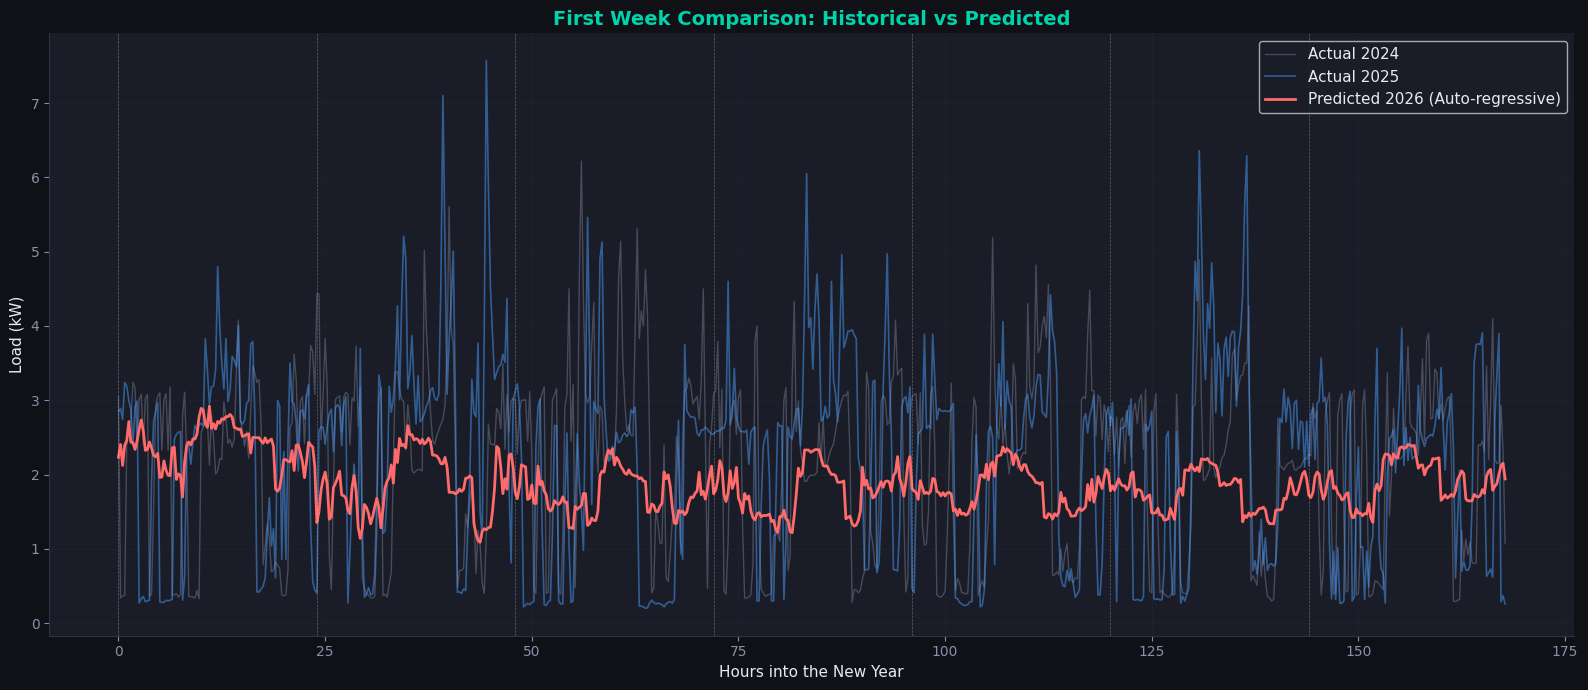

In [32]:
# DEBUGGING & YEAR-OVER-YEAR COMPARISON
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(" 1. DEBUGGING THE FLAT LINE (Last Week of 2025)")

# Extract the final week of 2025
end_of_2025 = df_combined_feat[
    (df_combined_feat['timestamp'] >= '2025-12-25') &
    (df_combined_feat['timestamp'] < '2026-01-01')
].copy()

end_of_2025['_date'] = end_of_2025['timestamp'].dt.date
debug_days = sorted(end_of_2025['_date'].unique())

print(f"{'Date':<15} | {'Daily Mean':<12} | {'Daily Max':<12} | {'Next Day Cap':<15}")
print("-" * 65)

for d in debug_days:
    day_data = end_of_2025[end_of_2025['_date'] == d]
    day_mean = day_data['load_p'].mean()
    day_max  = day_data['load_p'].max()

    # Simulate the relaxed Standby Cap logic
    cap = float(np.interp(day_mean, [0.0, 0.3, 0.6], [0.5, 2.0, 99.0]))

    print(f"{str(d):<15} | {day_mean:>7.3f} kW | {day_max:>7.3f} kW | {cap:>10.2f} kW")




print("\n================================================================")
print(" 2. YEAR-OVER-YEAR COMPARISON (Week 1 of 2024, 2025, 2026)")
print("================================================================")

# Safely extract exactly 7 days (672 steps) of data for each year
steps = 96 * 7

w1_2024 = df_combined_feat[
    (df_combined_feat['timestamp'] >= '2024-01-01')
]['load_p'].values[:steps]

w1_2025 = df_combined_feat[
    (df_combined_feat['timestamp'] >= '2025-01-01')
]['load_p'].values[:steps]

# 'submission' contains your 2026 forecast from Experiment C
w1_2026 = submission['load_forecast'].values[:steps]

# Create a common X-axis (Hours into the year)
hours = np.arange(steps) / 4.0

fig, ax = plt.subplots(figsize=(16, 7))

# Plot historicals as background context
if len(w1_2024) == steps:
    ax.plot(hours, w1_2024, label='Actual 2024', color='#8b8fa8', alpha=0.4, lw=1)
if len(w1_2025) == steps:
    ax.plot(hours, w1_2025, label='Actual 2025', color='#4a9eff', alpha=0.5, lw=1.2)

# Plot the 2026 prediction bold and up front
if len(w1_2026) == steps:
    ax.plot(hours, w1_2026, label='Predicted 2026 (Auto-regressive)', color='#ff6b6b', lw=2)

ax.set_title('First Week Comparison: Historical vs Predicted', fontsize=14, fontweight='bold', color='#00d4aa')
ax.set_ylabel('Load (kW)', fontsize=11)
ax.set_xlabel('Hours into the New Year', fontsize=11)

# Add vertical lines for midnight
for h in range(0, int(hours[-1]), 24):
    ax.axvline(h, color='white', linestyle='--', linewidth=0.5, alpha=0.3)

ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('Data/output/YoY_comparison.png', dpi=120, facecolor='#0f1117', bbox_inches='tight')
plt.show()

#Optimizer

In [33]:

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import time, warnings
warnings.filterwarnings('ignore')

print("================================================================")
print(" PHASE 0: FEATURE ENGINEERING")
print("================================================================")

# Create the engineered features on our newly cleaned df_full
print("Generating lags, weather features, and time contexts...")
df_full_feat = engineer_features(df_full, weather_df, holiday_df)


print("\n================================================================")
print(" PHASE 1: DAY-AHEAD RECURSIVE FORECAST (FULL YEAR 2025)")
print("================================================================")

# 1. Train the model strictly on 2024 data using the FEATURED dataset
model_2024 = train_model(
    df_full_feat, SAFE_FEATURES, TARGET_COL,
    train_end='2025-01-01',
    val_months=2, # Validates on Nov & Dec 2024
)

# 2. Generate the recursive forecast for all 365 days of 2025
df_2025_opt, pred_2025 = recursive_day_ahead(
    model_2024, df_full_feat, SAFE_FEATURES, TARGET_COL,
    test_start='2025-01-01',
    test_end='2026-01-01',
    label='Full Year 2025'
)


 PHASE 0: FEATURE ENGINEERING
Generating lags, weather features, and time contexts...

 PHASE 1: DAY-AHEAD RECURSIVE FORECAST (FULL YEAR 2025)
Training up to: 2025-01-01
  Train : 27,936 rows  (up to 2024-11-01)
  Val   : 5,856 rows  (2024-11-01 → 2025-01-01)
[0]	validation_0-rmse:1.39583
[100]	validation_0-rmse:1.10790
[200]	validation_0-rmse:1.12117
[249]	validation_0-rmse:1.12664

── Validation (last 2 months) ──
  RMSE  = 1.1078 kW
  MAE   = 0.8747 kW
  NRMSE = 58.39%

Running Full Year 2025: 2025-01-01 → 2026-01-01 (365 days)

── Full Year 2025 (2025-01-01 → 2026-01-01) ──
  RMSE  = 1.0327 kW
  MAE   = 0.7688 kW
  NRMSE = 69.87%


In [34]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time, warnings
warnings.filterwarnings('ignore')

# ── SYSTEM CONSTANTS ─────────────────────────────────────────
BAT_CAP  = 16.0
BAT_MAX  = 8.0
ETA      = np.sqrt(0.90)
GRID_MAX = 6.0
SOC_INIT = 0.50
DT       = 0.25

df_opt = df_2025_opt.copy()
df_opt = df_opt.rename(columns={'load_p': 'load', 'pv_p': 'pv'})
df_opt['load_forecast'] = pred_2025

N = len(df_opt)
load       = df_opt['load'].values
pv         = df_opt['pv'].values
buy_price  = df_opt['buy_price'].values
sell_price = df_opt['selling_price_eur_kwh'].values
p_bat_A    = df_opt['battery_p'].values

# ── COST FUNCTION ────────────────────────────────────────────
def compute_bill(load, pv, p_battery, buy_price, sell_price, dt=DT):
    p_grid   = load - pv - p_battery
    cost_imp = np.maximum( p_grid, 0) * buy_price  * dt
    rev_exp  = np.maximum(-p_grid, 0) * sell_price * dt
    bill     = cost_imp - rev_exp
    return bill.sum(), bill, p_grid

# ── BASELINES ────────────────────────────────────────────────
bill_B, _, _  = compute_bill(load, pv, np.zeros(N), buy_price, sell_price)
bill_A, _, _  = compute_bill(load, pv, p_bat_A,     buy_price, sell_price)
print(f"  Baseline B (Zero-Intelligence): €{bill_B:,.2f}")
print(f"  Baseline A (Historical Op)    : €{bill_A:,.2f}")

# ── SINGLE-DAY LP SOLVER ─────────────────────────────────────
def solve_day_lp(load_day, pv_day, buy_day, sell_day,soc_init,
                 standby_cap=None,
                 pv_tomorrow=None,
                 bat_cap=BAT_CAP, bat_max=BAT_MAX,
                 eta=ETA, grid_max=GRID_MAX, dt=DT):
    H = len(load_day)

    # ── Decision variables ────────────────────────────────────
    p_bat_charge = cp.Variable(H, nonneg=True)   # energy into battery (≥0)
    p_bat_disch  = cp.Variable(H, nonneg=True)   # energy out of battery (≥0)
    soc          = cp.Variable(H + 1)

    # ── Derived quantities (not variables) ────────────────────
    p_bat  = p_bat_disch - p_bat_charge          # net battery power
    p_grid = load_day - pv_day - p_bat           # grid power (+ = import)

    # Split grid into import/export for objective
    p_grid_pos = cp.Variable(H, nonneg=True)     # import (costs money)
    p_grid_neg = cp.Variable(H, nonneg=True)     # export (earns money)

    # ── Objective ─────────────────────────────────────────────
    # Today's bill
    bill = cp.sum(
        cp.multiply(p_grid_pos, buy_day) -
        cp.multiply(p_grid_neg, sell_day)
    ) * dt

    # Terminal value: reward SoC at end of day
    # Value = what that stored energy saves tomorrow
    # = buy_price * eta (discharge efficiency) * stored_kWh
    # Discounted by PV coverage tomorrow (less valuable if sun will recharge anyway)
    avg_buy      = float(np.mean(buy_day))
    if pv_tomorrow is not None:
        load_kwh_today  = float(np.sum(load_day)) * dt
        pv_kwh_tomorrow = float(np.sum(pv_tomorrow)) * dt
        # Fraction of tomorrow's load that PV covers (0 to 1)
        pv_cover = float(np.clip(pv_kwh_tomorrow / (load_kwh_today + 0.1), 0, 1))
    else:
        pv_cover = 0.0

    # When pv_cover=1: terminal value = 0.4 × avg_buy (PV will recharge anyway)
    # When pv_cover=0: terminal value = 1.0 × avg_buy (that SoC is precious)
    terminal_value  = avg_buy * eta * (1.0 - 0.6 * pv_cover)
    terminal_reward = terminal_value * soc[H] * bat_cap

    objective = cp.Minimize(bill - terminal_reward)

    # ── Constraints ───────────────────────────────────────────
    constraints = [
        # Grid balance split
        p_grid_pos - p_grid_neg == p_grid,
        p_grid_pos <= grid_max,
        p_grid_neg <= grid_max,

        # Battery power limits
        p_bat_charge <= bat_max,
        p_bat_disch  <= bat_max,

        # cannot charge AND discharge simultaneously
        # (soft enforcement via cost — exact would need binary var)
        # In practice LP won't do both since it wastes energy

        # Grid limit on battery power too
        p_bat_disch - p_bat_charge >= -bat_max,
        p_bat_disch - p_bat_charge <=  bat_max,

        # SoC dynamics
        soc[0] == soc_init,
        soc >= 0.05,   # 5% minimum buffer only
        soc <= 1.0,
    ] + [
        soc[t+1] == soc[t]
                  + p_bat_charge[t] * eta * dt / bat_cap
                  - p_bat_disch[t]  / eta * dt / bat_cap
        for t in range(H)
    ]

    if standby_cap is not None:
        # If we are in standby mode, don't let the battery discharge
        # faster than the cap (plus a small buffer)
        constraints += [p_bat_disch <= standby_cap + 0.2]


    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, warm_start=True)

    if prob.status not in ['optimal', 'optimal_inaccurate']:
        return np.zeros(H), float(soc_init)

    return (p_bat_disch.value - p_bat_charge.value), float(soc.value[-1])


def run_daily_mpc(load_input, pv_input, buy_price, sell_price,
                  soc_init=SOC_INIT, label='MPC', H=96):
    days       = N // 96
    p_bat_out  = np.zeros(N)
    soc_out    = np.zeros(N + 1)
    soc_out[0] = soc_init

    print(f"\nRunning {label} (H={H}, {days} LP solves)...")
    t0 = time.time()

    for d in range(days):
        t_start = d * 96
        t_end   = min(t_start + H, N)
        window  = t_end - t_start

        # Tomorrow's ACTUAL PV for oracle / FORECAST PV for MPC
        # Both are passed in as pv_input — caller decides which to use
        tmrw_s = t_end
        tmrw_e = min(tmrw_s + 96, N)
        pv_tmrw = pv_input[tmrw_s:tmrw_e] if tmrw_e > tmrw_s else None

        p_bat_day, soc_end = solve_day_lp(
            load_input[t_start:t_end],
            pv_input[t_start:t_end],      # PV for today
            buy_price[t_start:t_end],
            sell_price[t_start:t_end],
            soc_init    = soc_out[t_start],
            pv_tomorrow = pv_tmrw,
        )

        for step in range(window):
            t            = t_start + step
            p_bat_t      = float(np.clip(p_bat_day[step], -BAT_MAX, BAT_MAX))
            p_bat_out[t] = p_bat_t

            if p_bat_t < 0:
                soc_out[t+1] = soc_out[t] + (-p_bat_t) * ETA * DT / BAT_CAP
            else:
                soc_out[t+1] = soc_out[t] -  p_bat_t  / ETA * DT / BAT_CAP
            soc_out[t+1] = float(np.clip(soc_out[t+1], 0.0, 1.0))

        if d % 30 == 0:
            print(f"  Day {d+1:3d}/{days}  SoC={soc_out[t_end]:.2f}  "
                  f"elapsed={time.time()-t0:.1f}s")

    print(f"  Finished in {time.time()-t0:.1f}s")
    bill, bill_arr, p_grid = compute_bill(
        load, pv, p_bat_out, buy_price, sell_price)
    return p_bat_out, soc_out, p_grid, bill, bill_arr


# ── RUN ALL FOUR SCENARIOS ────────────────────────────────────
# For each test month, slice the data and run independently

for month_label, m_start, m_end in [
    ('April 2025',     '2025-04-01', '2025-05-01'),
    ('September 2025', '2025-09-01', '2025-10-01'),
]:
    mask = (df_opt['timestamp'] >= m_start) & (df_opt['timestamp'] < m_end)
    idx  = df_opt.index[mask]

    load_m      = load[idx]
    pv_m        = pv[idx]
    buy_m       = buy_price[idx]
    sell_m      = sell_price[idx]
    p_bat_A_m   = p_bat_A[idx]
    load_fcst_m = df_opt.loc[idx, 'load_forecast'].values
    N_m         = len(load_m)

    # Redefine N for the month slice inside run_daily_mpc
    # (we pass N_m via closure — cleaner to just inline)
    def solve_day_lp(load_day, pv_day, buy_day, sell_day,
                 soc_init, pv_tomorrow=None, standby_cap=None, # <--- Added standby_cap
                 bat_cap=BAT_CAP, bat_max=BAT_MAX,
                 eta=ETA, grid_max=GRID_MAX, dt=DT):
        H = len(load_day)

        # ── Decision variables ────────────────────────────────────
        p_bat_charge = cp.Variable(H, nonneg=True)
        p_bat_disch  = cp.Variable(H, nonneg=True)
        soc          = cp.Variable(H + 1)
        p_grid_pos   = cp.Variable(H, nonneg=True)
        p_grid_neg   = cp.Variable(H, nonneg=True)

        # ── Derived quantities ────────────────────────────────────
        p_bat  = p_bat_disch - p_bat_charge
        p_grid = load_day - pv_day - p_bat

        # ── Objective ─────────────────────────────────────────────
        bill = cp.sum(cp.multiply(p_grid_pos, buy_day) - cp.multiply(p_grid_neg, sell_day)) * dt

        # Terminal Value logic: Reward the battery for staying full for tomorrow
        avg_buy = float(np.mean(buy_day))
        tomorrow_peak = float(np.max(buy_day)) # Assume tomorrow's peak matches today's

        if pv_tomorrow is not None:
            load_kwh_today  = float(np.sum(load_day)) * dt
            pv_kwh_tomorrow = float(np.sum(pv_tomorrow)) * dt
            pv_cover = float(np.clip(pv_kwh_tomorrow / (load_kwh_today + 0.1), 0, 1))
        else:
            pv_cover = 0.0

        # IMPROVED: Higher valuation (1.1 instead of 1.0) to prevent late-night dumping
        terminal_value  = tomorrow_peak * eta * (1.1 - 0.5 * pv_cover)
        terminal_reward = terminal_value * soc[H] * bat_cap

        objective = cp.Minimize(bill - terminal_reward)

        # ── Constraints ───────────────────────────────────────────
        constraints = [
            p_grid_pos - p_grid_neg == p_grid,
            p_grid_pos <= grid_max,
            p_grid_neg <= grid_max,
            p_bat_charge <= bat_max,
            p_bat_disch  <= bat_max,
            soc[0] == soc_init,
            soc >= 0.05, # Keep a 5% safety buffer
            soc <= 1.0,
        ]

        # ADDED: Standby Cap Constraint
        # If the day is predicted to be a "standby" day, limit discharge power
        if standby_cap is not None:
            constraints += [p_bat_disch <= standby_cap + 0.2] # 0.2kW buffer for surges

        for t in range(H):
            constraints += [
                soc[t+1] == soc[t] + p_bat_charge[t] * eta * dt / bat_cap - p_bat_disch[t] / eta * dt / bat_cap
            ]

        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.CLARABEL, warm_start=True)

        if prob.status not in ['optimal', 'optimal_inaccurate']:
            return np.zeros(H), float(soc_init)

        return (p_bat_disch.value - p_bat_charge.value), float(soc.value[-1])

    print(f"\n{'='*55}")
    print(f"  {month_label}")
    print(f"{'='*55}")

    bill_B_m, _, _ = compute_bill(load_m, pv_m, np.zeros(N_m), buy_m, sell_m)
    bill_A_m, _, _ = compute_bill(load_m, pv_m, p_bat_A_m,     buy_m, sell_m)
    print(f"  {'Baseline B':<30} €{bill_B_m:,.2f}")
    print(f"  {'Baseline A':<30} €{bill_A_m:,.2f}")

    _, _, _, bill_oracle_m = run_month_mpc(load_m,      pv_m,        'Oracle MPC')
    _, _, _, bill_mpc_m    = run_month_mpc(load_fcst_m, pv_m,        'Forecast MPC')

    print(f"\n  {'Controller':<30} {'Bill':>8} {'vs B':>8} {'vs A':>8}")
    print(f"  {'-'*52}")
    print(f"  {'Baseline B':<30} €{bill_B_m:>6,.2f}")
    print(f"  {'Baseline A':<30} €{bill_A_m:>6,.2f}  "
          f"{(bill_B_m-bill_A_m)/bill_B_m*100:>6.1f}%")
    print(f"  {'Forecast MPC':<30} €{bill_mpc_m:>6,.2f}  "
          f"{(bill_B_m-bill_mpc_m)/bill_B_m*100:>6.1f}%  "
          f"{(bill_A_m-bill_mpc_m)/bill_A_m*100:>6.1f}%")
    print(f"  {'Oracle MPC':<30} €{bill_oracle_m:>6,.2f}  "
          f"{(bill_B_m-bill_oracle_m)/bill_B_m*100:>6.1f}%  "
          f"{(bill_A_m-bill_oracle_m)/bill_A_m*100:>6.1f}%")
    oracle_gap = bill_mpc_m - bill_oracle_m
    print(f"\n  Oracle gap: €{oracle_gap:.2f} "
          f"({oracle_gap/bill_oracle_m*100:.1f}%)")
    print(f"  → How much better you'd do with perfect load forecast")

  Baseline B (Zero-Intelligence): €1,611.95
  Baseline A (Historical Op)    : €1,230.24

  April 2025
  Baseline B                     €25.87
  Baseline A                     €-9.29


NameError: name 'run_month_mpc' is not defined

In [ ]:
# ── EMERGENCY DIAGNOSTICS — run before MPC ───────────────────
print('=== DATA SANITY CHECK ===')

# 1. Are PV values actually non-zero?
print(f'PV: mean={pv.mean():.3f}  max={pv.max():.3f}  '
      f'non-zero steps={( pv > 0).sum():,} / {len(pv):,}')

# 2. What does sell_price look like vs buy_price?
print(f'sell_price: mean={sell_price.mean():.4f}  '
      f'min={sell_price.min():.4f}  max={sell_price.max():.4f}')
print(f'buy_price : mean={buy_price.mean():.4f}  '
      f'min={buy_price.min():.4f}  max={buy_price.max():.4f}')

# 3. Check sell > buy (would force LP to always export, draining battery)
sell_gt_buy = (sell_price > buy_price).sum()
print(f'Steps where sell > buy: {sell_gt_buy:,}  '
      f'({sell_gt_buy/len(sell_price)*100:.1f}%)')

# 4. Check the actual column names in df_opt
print(f'\ndf_opt columns: {df_opt.columns.tolist()}')

# 5. Manually run one day LP and inspect the solution
print('\n=== DAY 1 LP INSPECTION ===')
import cvxpy as cp

day0_load = load[:96]
day0_pv   = pv[:96]
day0_buy  = buy_price[:96]
day0_sell = sell_price[:96]

print(f'Day 1 load : mean={day0_load.mean():.3f}  max={day0_load.max():.3f}')
print(f'Day 1 pv   : mean={day0_pv.mean():.3f}    max={day0_pv.max():.3f}')
print(f'Day 1 buy  : mean={day0_buy.mean():.4f}')
print(f'Day 1 sell : mean={day0_sell.mean():.4f}')

p_bat_test, soc_end = solve_day_lp(
    day0_load, day0_pv, day0_buy, day0_sell, soc_init=0.50)

print(f'\nLP result:')
print(f'  p_bat mean    : {p_bat_test.mean():.4f} kW')
print(f'  p_bat max     : {p_bat_test.max():.4f} kW  (discharge)')
print(f'  p_bat min     : {p_bat_test.min():.4f} kW  (charge)')
print(f'  SoC end       : {soc_end:.4f}')
print(f'  Any charging? : {(p_bat_test < -0.01).sum()} steps')
print(f'  Any discharge?: {(p_bat_test >  0.01).sum()} steps')

# Show hourly pattern
print(f'\nHourly p_bat (first 24h):')
for h in range(24):
    slot = h * 4
    print(f'  {h:02d}:00  p_bat={p_bat_test[slot]:+.3f} kW  '
          f'pv={day0_pv[slot]:.2f}  buy={day0_buy[slot]:.4f}  '
          f'sell={day0_sell[slot]:.4f}')